# Medi-Intel Respiratory Differential Diagnosis — XGBoost Kaggle Research MVP v6.2.1

This notebook finalizes the synthetic DDXPlus baseline after the executed v6.1.1 audit.

## Preserved foundations

- Strict cross-split input-profile filtering
- Partial-history augmentation
- Three-state supported-scope policy
- Partial-history primary classifier
- Thirteen official-probability DDx regressors
- Four critical candidate-inclusion classifiers
- Five critical-pathology detection heads
- Closed-world and complete-official-DDx reporting
- Scope-gated portable inference and validated ZIP export

## v6.2 corrections

1. Restores the **original probability-ranked Top-5** as the only ranked differential.
2. Removes rank-5 replacement and all ranking-displacement logic.
3. Adds a separate, validation-tuned **critical considerations** list.
4. Allows at most two additional critical considerations per encounter.
5. Reports consideration recall, precision, false-addition rate, and list size.
6. Tunes critical-pathology thresholds to a 97% validation-sensitivity target while retaining a 95% test gate.
7. Evaluates half-history critical scope handling by **safe routing** (`SUPPORTED` or `INSUFFICIENT`) rather than demanding a forced supported decision.
8. Keeps exact float32 stage-specific scope thresholds from v6.1.1.
9. Calculates consultation completeness from backend questionnaire state.
10. Preserves critical-pathology signals during insufficient-information states.
11. Exports only one scope-gated inference path and a complete SHA-256 manifest.

## Important boundary

DDXPlus is synthetic. This notebook is an algorithm-development benchmark, not a clinical diagnostic, triage, treatment, prescription, or emergency-decision system.

## v6.2.1 correction

`k5` is now defined in the configuration cell before any ranking,
critical-consideration, evaluation, inference, or export cell uses it.
Later duplicate definitions were removed, and a clear execution-order
guard was added.


In [1]:
# =========================
# 1. Reproducibility/config
# =========================
SEED = 42
RUN_MODE = "standard"  # smoke | standard | full

RUN_CONFIGS = {
    "smoke": {
        "max_train_per_class": 2_000,
        "max_val_per_class": 500,
        "max_test_per_class": 500,
        "resp_partial_sample_fraction_per_level": 0.20,
        "scope_full_max_per_binary_class": 20_000,
        "scope_partial_per_binary_class": 5_000,
        "primary_estimators": 250,
        "primary_early_stopping": 25,
        "scope_estimators": 250,
        "scope_early_stopping": 25,
        "ddx_estimators": 300,
        "ddx_early_stopping": 30,
        "inclusion_estimators": 250,
        "inclusion_early_stopping": 25,
        "safety_estimators": 250,
        "safety_early_stopping": 25,
        "robustness_repeats": 2,
        "verbose_every": 10,
    },
    "standard": {
        "max_train_per_class": None,
        "max_val_per_class": None,
        "max_test_per_class": None,
        "resp_partial_sample_fraction_per_level": 0.25,
        "scope_full_max_per_binary_class": None,
        "scope_partial_per_binary_class": 75_000,
        "primary_estimators": 700,
        "primary_early_stopping": 60,
        "scope_estimators": 700,
        "scope_early_stopping": 60,
        "ddx_estimators": 1_000,
        "ddx_early_stopping": 80,
        "inclusion_estimators": 500,
        "inclusion_early_stopping": 50,
        "safety_estimators": 500,
        "safety_early_stopping": 50,
        "robustness_repeats": 3,
        "verbose_every": 25,
    },
    "full": {
        "max_train_per_class": None,
        "max_val_per_class": None,
        "max_test_per_class": None,
        "resp_partial_sample_fraction_per_level": 0.50,
        "scope_full_max_per_binary_class": None,
        "scope_partial_per_binary_class": 150_000,
        "primary_estimators": 1_000,
        "primary_early_stopping": 80,
        "scope_estimators": 1_000,
        "scope_early_stopping": 80,
        "ddx_estimators": 1_400,
        "ddx_early_stopping": 100,
        "inclusion_estimators": 700,
        "inclusion_early_stopping": 70,
        "safety_estimators": 700,
        "safety_early_stopping": 70,
        "robustness_repeats": 5,
        "verbose_every": 25,
    },
}

if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"RUN_MODE must be one of {sorted(RUN_CONFIGS)}")
RUN = RUN_CONFIGS[RUN_MODE]

RUN_DUPLICATE_AUDIT = True
DROP_CROSS_SPLIT_PROFILE_OVERLAP = True
RUN_PARTIAL_HISTORY_AUGMENTATION = True
RUN_SCOPE_MODEL = True
RUN_DDX_MODELS = True
RUN_INCLUSION_MODELS = True
RUN_SAFETY_HEADS = True
RUN_ROBUSTNESS_TESTS = True

# Synthetic history levels represent retained non-initial evidence.
EVALUATION_RETENTION_LEVELS = (1.00, 0.75, 0.50, 0.25, 0.00)
RESPIRATORY_TRAIN_PARTIAL_LEVELS = (0.75, 0.50, 0.25, 0.00)
SCOPE_TRAIN_PARTIAL_LEVELS = (0.75, 0.50)
AUGMENTED_VIEW_WEIGHT = 0.60

# Three-state supported-scope policy.
MIN_COMPLETION_FOR_SCOPE_DECISION = 0.50
MIN_NONINITIAL_EVIDENCE_FOR_SCOPE_DECISION = 2
SCOPE_HASH_FEATURES = 2 ** 13
SCOPE_MAX_VALIDATION_FALSE_ACCEPTANCE_RATE = 0.001
SCOPE_MAX_VALIDATION_FALSE_UNSUPPORTED_RATE = 0.001

# Primary/DDx settings.
DDX_POSITIVE_SAMPLE_WEIGHT = 4.0
TARGET_PRIMARY_COVERAGE = 0.90

# Separate critical-consideration list. The base Top-5 is never modified.
CRITICAL_CONSIDERATION_TARGET_RECALL = 0.80
CRITICAL_CONSIDERATION_THRESHOLD_GRID_SIZE = 81
CRITICAL_CONSIDERATION_MIN_PRECISION = 0.20
MAX_CRITICAL_CONSIDERATIONS_PER_CASE = 2

CRITICAL_RESPIRATORY_CONDITIONS = [
    "Bronchospasm / acute asthma exacerbation",
    "Pneumonia",
    "Pulmonary embolism",
    "Spontaneous pneumothorax",
    "Tuberculosis",
]
CRITICAL_CONSIDERATION_TARGET_CONDITIONS = [
    "Bronchospasm / acute asthma exacerbation",
    "Pulmonary embolism",
    "Spontaneous pneumothorax",
    "Tuberculosis",
]
SAFETY_TARGET_SENSITIVITY = 0.97

# Proposed synthetic research gates — not clinical standards.
GATE_FULL_SCOPE_SUPPORTED_SENSITIVITY = 0.99
GATE_FULL_SCOPE_FALSE_ACCEPTANCE = 0.001
GATE_CRITICAL_SCOPE_SENSITIVITY = 0.99
GATE_HALF_HISTORY_SUPPORTED_SENSITIVITY = 0.95
GATE_HALF_HISTORY_FALSE_ACCEPTANCE = 0.003
GATE_HALF_CRITICAL_SAFE_ROUTING_RATE = 0.99
GATE_INITIAL_INSUFFICIENT_RATE = 0.95
GATE_CRITICAL_VISIBILITY_RECALL = 0.80
GATE_HALF_CRITICAL_VISIBILITY_RECALL = 0.70
GATE_CRITICAL_CONSIDERATION_PRECISION = 0.20
GATE_CRITICAL_CONSIDERATION_FALSE_RATE = 0.02
GATE_SAFETY_HEAD_SENSITIVITY = 0.95
GATE_HALF_SAFETY_HEAD_FALSE_POSITIVE_RATE = 0.05

RESPIRATORY_PATHOLOGIES = [
    "Acute COPD exacerbation / infection",
    "Acute laryngitis",
    "Bronchiectasis",
    "Bronchitis",
    "Bronchospasm / acute asthma exacerbation",
    "Influenza",
    "Pneumonia",
    "Pulmonary embolism",
    "Pulmonary neoplasm",
    "Spontaneous pneumothorax",
    "Tuberculosis",
    "URTI",
    "Viral pharyngitis",
]

ARTIFACT_DIR = "/kaggle/working/respiratory_ddx_artifacts_v6_2_1"
ZIP_BASENAME = "/kaggle/working/respiratory_ddx_results_v6_2_1"

print("Run mode:", RUN_MODE)
print(RUN)

# Number of differential candidates shown and evaluated.
k5 = 5


Run mode: standard
{'max_train_per_class': None, 'max_val_per_class': None, 'max_test_per_class': None, 'resp_partial_sample_fraction_per_level': 0.25, 'scope_full_max_per_binary_class': None, 'scope_partial_per_binary_class': 75000, 'primary_estimators': 700, 'primary_early_stopping': 60, 'scope_estimators': 700, 'scope_early_stopping': 60, 'ddx_estimators': 1000, 'ddx_early_stopping': 80, 'inclusion_estimators': 500, 'inclusion_early_stopping': 50, 'safety_estimators': 500, 'safety_early_stopping': 50, 'robustness_repeats': 3, 'verbose_every': 25}


In [2]:
# =========================
# 2. Imports and GPU check
# =========================
import ast
import gc
import hashlib
import json
import math
import os
import platform
import random
import re
import shutil
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.optimize import minimize_scalar

import sklearn
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    label_ranking_average_precision_score,
    log_loss,
    ndcg_score,
    precision_score,
    recall_score,
    roc_auc_score,
    top_k_accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb
from packaging import version
from IPython.display import FileLink, display

warnings.filterwarnings("ignore")
random.seed(SEED)
np.random.seed(SEED)

if os.path.exists(ARTIFACT_DIR):
    shutil.rmtree(ARTIFACT_DIR)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Remove any ZIP left by an older or interrupted run.
stale_zip_path = ZIP_BASENAME + ".zip"
if os.path.exists(stale_zip_path):
    os.remove(stale_zip_path)

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgb.__version__)

try:
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError("No CUDA GPU detected.")
    GPU_NAME = torch.cuda.get_device_name(0)
    print("GPU:", GPU_NAME)
except Exception as exc:
    raise RuntimeError(
        "Enable a Kaggle GPU: Settings -> Accelerator -> GPU."
    ) from exc

if version.parse(xgb.__version__) < version.parse("1.6.0"):
    raise RuntimeError("XGBoost >= 1.6 is required.")

XGB_VERSION = version.parse(xgb.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas: 2.3.3
scikit-learn: 1.6.1
xgboost: 3.2.0
GPU: Tesla P100-PCIE-16GB


## Required Kaggle input

Attach the same DDXPlus split files used in v6.

For doctor-readable questions, also attach:

- `release_evidences.json`
- `release_conditions.json`

The modelling pipeline can run without these JSON files, but the exported readiness status will remain false and next-question output will contain evidence codes rather than usable clinical wording.

In [3]:
# =====================================
# 3. Discover DDXPlus files recursively
# =====================================
KAGGLE_INPUT = Path("/kaggle/input")
mounted_files = [path for path in KAGGLE_INPUT.rglob("*") if path.is_file()]

if not mounted_files:
    raise FileNotFoundError(
        "No Kaggle input files are mounted. Attach the DDXPlus dataset."
    )


def find_one(patterns, required=True):
    for pattern in patterns:
        matches = sorted(KAGGLE_INPUT.rglob(pattern))
        if matches:
            selected = matches[0]
            if len(matches) > 1:
                print(f"Multiple matches for {pattern}; using {selected}")
            return selected
    if required:
        preview = "\n".join(str(path) for path in mounted_files[:200])
        raise FileNotFoundError(
            f"Could not find any of {patterns}. Mounted files include:\n{preview}"
        )
    return None


TRAIN_PATH = find_one([
    "release_train_patients.csv",
    "release_train_patients.zip",
    "train.csv",
])
VAL_PATH = find_one([
    "release_validate_patients.csv",
    "release_validate_patients.zip",
    "validate.csv",
    "validation.csv",
    "val.csv",
])
TEST_PATH = find_one([
    "release_test_patients.csv",
    "release_test_patients.zip",
    "test.csv",
])
EVIDENCES_PATH = find_one(
    ["release_evidences.json", "evidences.json"],
    required=False,
)
CONDITIONS_PATH = find_one(
    ["release_conditions.json", "conditions.json"],
    required=False,
)

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)
print("Evidence metadata:", EVIDENCES_PATH)
print("Condition metadata:", CONDITIONS_PATH)

Train: /kaggle/input/datasets/chandashekar8/ddxplus/train.csv
Validation: /kaggle/input/datasets/chandashekar8/ddxplus/validate.csv
Test: /kaggle/input/datasets/chandashekar8/ddxplus/test.csv
Evidence metadata: None
Condition metadata: None


In [4]:
# ===========================
# 4. Load and validate splits
# ===========================
REQUIRED_COLUMNS = {
    "AGE",
    "SEX",
    "PATHOLOGY",
    "EVIDENCES",
    "INITIAL_EVIDENCE",
    "DIFFERENTIAL_DIAGNOSIS",
}


def read_ddxplus(path: Path) -> pd.DataFrame:
    start = time.perf_counter()
    frame = pd.read_csv(
        path,
        usecols=lambda column: column in REQUIRED_COLUMNS,
        low_memory=False,
    )
    missing = REQUIRED_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing: {sorted(missing)}")
    print(
        f"Loaded {path.name}: {frame.shape} "
        f"in {(time.perf_counter() - start) / 60:.2f} min"
    )
    return frame


train_raw = read_ddxplus(TRAIN_PATH)
val_raw = read_ddxplus(VAL_PATH)
test_raw = read_ddxplus(TEST_PATH)

print("Total records:", len(train_raw) + len(val_raw) + len(test_raw))
print("Pathologies:", train_raw["PATHOLOGY"].nunique())
display(train_raw.head(3))

Loaded train.csv: (1025602, 6) in 0.26 min
Loaded validate.csv: (132448, 6) in 0.03 min
Loaded test.csv: (134529, 6) in 0.03 min
Total records: 1292579
Pathologies: 49


,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,18,"[['Bronchitis', 0.19171203430383882], ['Pneumo...",M,URTI,"['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...",E_91
1,21,"[['HIV (initial infection)', 0.518950056440760...",M,HIV (initial infection),"['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_...",E_50
2,19,"[['Bronchitis', 0.11278064619119596], ['Pneumo...",F,Pneumonia,"['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55...",E_77


In [5]:
# =========================================
# 5. Dataset and exact input-profile audit
# =========================================
raw_split_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "total"],
    "records": [
        len(train_raw),
        len(val_raw),
        len(test_raw),
        len(train_raw) + len(val_raw) + len(test_raw),
    ],
    "columns": [
        train_raw.shape[1],
        val_raw.shape[1],
        test_raw.shape[1],
        train_raw.shape[1],
    ],
    "pathologies": [
        train_raw["PATHOLOGY"].nunique(),
        val_raw["PATHOLOGY"].nunique(),
        test_raw["PATHOLOGY"].nunique(),
        len(
            set(train_raw["PATHOLOGY"])
            | set(val_raw["PATHOLOGY"])
            | set(test_raw["PATHOLOGY"])
        ),
    ],
})

full_class_counts = pd.concat([
    train_raw["PATHOLOGY"].value_counts().rename("train"),
    val_raw["PATHOLOGY"].value_counts().rename("validation"),
    test_raw["PATHOLOGY"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int).sort_index()
full_class_counts["total"] = full_class_counts.sum(axis=1)

age_audit = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "minimum_age": [train_raw.AGE.min(), val_raw.AGE.min(), test_raw.AGE.min()],
    "median_age": [train_raw.AGE.median(), val_raw.AGE.median(), test_raw.AGE.median()],
    "maximum_age": [train_raw.AGE.max(), val_raw.AGE.max(), test_raw.AGE.max()],
})

sex_counts = pd.concat([
    train_raw["SEX"].value_counts(dropna=False).rename("train"),
    val_raw["SEX"].value_counts(dropna=False).rename("validation"),
    test_raw["SEX"].value_counts(dropna=False).rename("test"),
], axis=1).fillna(0).astype(int)


def raw_profile_hash_array(frame):
    return pd.util.hash_pandas_object(
        frame[["AGE", "SEX", "EVIDENCES", "INITIAL_EVIDENCE"]],
        index=False,
    ).to_numpy(dtype=np.uint64)


duplicate_audit = {"audit_enabled": bool(RUN_DUPLICATE_AUDIT)}
if RUN_DUPLICATE_AUDIT:
    train_hashes_unique = np.unique(raw_profile_hash_array(train_raw))
    val_hashes_unique = np.unique(raw_profile_hash_array(val_raw))
    test_hashes_unique = np.unique(raw_profile_hash_array(test_raw))
    duplicate_audit.update({
        "train_records": int(len(train_raw)),
        "train_unique_profiles": int(len(train_hashes_unique)),
        "validation_records": int(len(val_raw)),
        "validation_unique_profiles": int(len(val_hashes_unique)),
        "test_records": int(len(test_raw)),
        "test_unique_profiles": int(len(test_hashes_unique)),
        "train_validation_profile_overlap": int(
            np.intersect1d(train_hashes_unique, val_hashes_unique).size
        ),
        "train_test_profile_overlap": int(
            np.intersect1d(train_hashes_unique, test_hashes_unique).size
        ),
        "validation_test_profile_overlap": int(
            np.intersect1d(val_hashes_unique, test_hashes_unique).size
        ),
    })

display(raw_split_summary)
display(full_class_counts)
display(age_audit)
display(sex_counts)
display(pd.Series(duplicate_audit, name="value").to_frame())

,split,records,columns,pathologies
0,train,1025602,6,49
1,validation,132448,6,49
2,test,134529,6,49
3,total,1292579,6,49


,train,validation,test,total
PATHOLOGY,,,,
Acute COPD exacerbation / infection,17661,2076,2153,21890
Acute dystonic reactions,25982,3281,3302,32565
Acute laryngitis,24129,3407,3217,30753
Acute otitis media,25917,3474,3516,32907
Acute pulmonary edema,19018,2500,2598,24116
Acute rhinosinusitis,13578,1866,1829,17273
Allergic sinusitis,26203,2136,2411,30750
Anaphylaxis,27718,3754,3799,35271
Anemia,50665,6903,6842,64410


,split,minimum_age,median_age,maximum_age
0,train,0,39.0,109
1,validation,0,39.0,109
2,test,0,39.0,109


,train,validation,test
SEX,,,
F,527798,68133,69342
M,497804,64315,65187


,value
audit_enabled,True
train_records,1025602
train_unique_profiles,1012347
validation_records,132448
validation_unique_profiles,132373
test_records,134529
test_unique_profiles,134428
train_validation_profile_overlap,1788
train_test_profile_overlap,1965
validation_test_profile_overlap,172


In [6]:
# =====================================================
# 6. Parsing helpers and optional evidence-code decoding
# =====================================================
EVIDENCE_TOKEN_REGEX = re.compile(r"E_\d+(?:_@_V_\d+)?")


def safe_literal_list(value, field_name):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(str(value))
    except (ValueError, SyntaxError) as exc:
        raise ValueError(
            f"Malformed {field_name}: {str(value)[:160]}"
        ) from exc
    if not isinstance(parsed, list):
        raise TypeError(f"{field_name} must parse to a list.")
    return parsed


def parse_evidence_list(value):
    return [str(item) for item in safe_literal_list(value, "EVIDENCES")]


def parse_differential(value):
    parsed = safe_literal_list(value, "DIFFERENTIAL_DIAGNOSIS")
    output = []
    for item in parsed:
        if not isinstance(item, (list, tuple)) or len(item) < 2:
            continue
        try:
            probability = float(item[1])
        except (TypeError, ValueError):
            continue
        if probability >= 0:
            output.append((str(item[0]), probability))
    return output


def extract_evidence_codes_from_raw(value):
    return EVIDENCE_TOKEN_REGEX.findall(str(value))


def evidence_base_code(code):
    return str(code).split("_@_", 1)[0]


def load_json_optional(path):
    if path is None:
        return {}
    with open(path, "r", encoding="utf-8") as file:
        loaded = json.load(file)
    return loaded if isinstance(loaded, dict) else {}


evidence_metadata_raw = load_json_optional(EVIDENCES_PATH)
condition_metadata_raw = load_json_optional(CONDITIONS_PATH)


def metadata_text(details):
    if not isinstance(details, dict):
        return None
    for key in (
        "question_en", "question", "name_en", "name",
        "description_en", "description",
    ):
        value = details.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()
    return None


def decode_evidence_code(code):
    code = str(code)
    base = evidence_base_code(code)
    details = evidence_metadata_raw.get(base, {})
    question = metadata_text(details)
    value_text = None

    if "_@_" in code and isinstance(details, dict):
        value_code = code.split("_@_", 1)[1]
        possible = (
            details.get("possible-values")
            or details.get("possible_values")
            or details.get("values")
        )
        if isinstance(possible, dict):
            candidate = possible.get(value_code) or possible.get(code)
            if isinstance(candidate, dict):
                value_text = metadata_text(candidate)
            elif candidate is not None:
                value_text = str(candidate)
        elif isinstance(possible, list):
            for item in possible:
                if isinstance(item, dict):
                    item_code = str(
                        item.get("id")
                        or item.get("value")
                        or item.get("code")
                        or ""
                    )
                    if item_code in {value_code, code}:
                        value_text = metadata_text(item) or item_code
                        break

    return {
        "evidence_code": code,
        "base_evidence_code": base,
        "question": question,
        "value": value_text,
        "doctor_readable": bool(question),
    }


print("Evidence metadata available:", bool(evidence_metadata_raw))
print("Condition metadata available:", bool(condition_metadata_raw))

Evidence metadata available: False
Condition metadata available: False


In [7]:
# ======================================================
# 7. Supported scope, strict splits, and natural counts
# ======================================================
train_labels = set(train_raw["PATHOLOGY"].dropna().unique())
val_labels = set(val_raw["PATHOLOGY"].dropna().unique())
test_labels = set(test_raw["PATHOLOGY"].dropna().unique())
available_in_all = train_labels & val_labels & test_labels

active_pathologies = [
    pathology for pathology in RESPIRATORY_PATHOLOGIES
    if pathology in available_in_all
]
missing_targets = [
    pathology for pathology in RESPIRATORY_PATHOLOGIES
    if pathology not in available_in_all
]

if missing_targets:
    raise RuntimeError(
        "Configured respiratory labels missing from a split: "
        + ", ".join(missing_targets)
    )
if len(active_pathologies) != len(RESPIRATORY_PATHOLOGIES):
    raise RuntimeError("The expected 13-condition scope was not found.")

respiratory_full_counts = full_class_counts.reindex(active_pathologies)


def filter_and_optional_cap(frame, labels, max_per_class, seed):
    filtered = frame[frame["PATHOLOGY"].isin(labels)].copy()
    if max_per_class is None:
        return filtered.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    groups = []
    for pathology in labels:
        group = filtered[filtered["PATHOLOGY"] == pathology]
        groups.append(group.sample(
            n=min(len(group), max_per_class),
            random_state=seed,
        ))
    return pd.concat(groups, ignore_index=True).sample(
        frac=1.0,
        random_state=seed,
    ).reset_index(drop=True)


# Full-training hashes are used for every strict evaluation.
full_train_profile_hashes = np.unique(raw_profile_hash_array(train_raw))
raw_val_hashes = raw_profile_hash_array(val_raw)
strict_val_keep = ~np.isin(raw_val_hashes, full_train_profile_hashes)
strict_full_val_hashes = np.unique(raw_val_hashes[strict_val_keep])

raw_test_hashes = raw_profile_hash_array(test_raw)
strict_test_keep = ~(
    np.isin(raw_test_hashes, full_train_profile_hashes)
    | np.isin(raw_test_hashes, strict_full_val_hashes)
)

SCOPE_FRAME_COLUMNS = [
    "AGE",
    "SEX",
    "PATHOLOGY",
    "EVIDENCES",
    "INITIAL_EVIDENCE",
]
scope_train_df = train_raw[SCOPE_FRAME_COLUMNS].copy()
scope_train_df["IS_SUPPORTED_SCOPE"] = (
    scope_train_df["PATHOLOGY"].isin(active_pathologies)
).astype(np.int8)

scope_val_df = val_raw.loc[
    strict_val_keep,
    SCOPE_FRAME_COLUMNS,
].copy().reset_index(drop=True)
scope_val_df["IS_SUPPORTED_SCOPE"] = (
    scope_val_df["PATHOLOGY"].isin(active_pathologies)
).astype(np.int8)

scope_test_df = test_raw.loc[
    strict_test_keep,
    SCOPE_FRAME_COLUMNS,
].copy().reset_index(drop=True)
scope_test_df["IS_SUPPORTED_SCOPE"] = (
    scope_test_df["PATHOLOGY"].isin(active_pathologies)
).astype(np.int8)

train_df = filter_and_optional_cap(
    train_raw,
    active_pathologies,
    RUN["max_train_per_class"],
    SEED,
)
val_df = filter_and_optional_cap(
    val_raw.loc[strict_val_keep],
    active_pathologies,
    RUN["max_val_per_class"],
    SEED,
)
test_df = filter_and_optional_cap(
    test_raw.loc[strict_test_keep],
    active_pathologies,
    RUN["max_test_per_class"],
    SEED,
)

strict_overlap_summary = {
    "validation_profiles_removed_against_full_training": int((~strict_val_keep).sum()),
    "test_profiles_removed_against_training_or_validation": int((~strict_test_keep).sum()),
    "strict_scope_validation_records": int(len(scope_val_df)),
    "strict_scope_test_records": int(len(scope_test_df)),
    "strict_respiratory_validation_records": int(len(val_df)),
    "strict_respiratory_test_records": int(len(test_df)),
}

respiratory_counts_used = pd.concat([
    train_df["PATHOLOGY"].value_counts().rename("train"),
    val_df["PATHOLOGY"].value_counts().rename("validation"),
    test_df["PATHOLOGY"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int).sort_index()
respiratory_counts_used["total"] = respiratory_counts_used.sum(axis=1)

print("Supported classes:", len(active_pathologies))
display(respiratory_full_counts)
display(pd.Series(strict_overlap_summary, name="value").to_frame())
display(respiratory_counts_used)

Supported classes: 13


,train,validation,test,total
PATHOLOGY,,,,
Acute COPD exacerbation / infection,17661,2076,2153,21890
Acute laryngitis,24129,3407,3217,30753
Bronchiectasis,18795,2319,2454,23568
Bronchitis,26400,3543,3594,33537
Bronchospasm / acute asthma exacerbation,19875,2209,2222,24306
Influenza,26812,3590,3554,33956
Pneumonia,25761,3484,3542,32787
Pulmonary embolism,27468,3725,3679,34872
Pulmonary neoplasm,14457,1891,1918,18266


,value
validation_profiles_removed_against_full_training,1808
test_profiles_removed_against_training_or_validation,2130
strict_scope_validation_records,130640
strict_scope_test_records,132399
strict_respiratory_validation_records,46125
strict_respiratory_test_records,46334


,train,validation,test,total
PATHOLOGY,,,,
Acute COPD exacerbation / infection,17661,1941,2007,21609
Acute laryngitis,24129,3407,3217,30753
Bronchiectasis,18795,2256,2373,23424
Bronchitis,26400,3543,3594,33537
Bronchospasm / acute asthma exacerbation,19875,2037,2017,23929
Influenza,26812,3590,3554,33956
Pneumonia,25761,3484,3542,32787
Pulmonary embolism,27468,3725,3679,34872
Pulmonary neoplasm,14457,1884,1908,18249


In [8]:
# ==========================================================
# 8. Prepare respiratory frames and official DDx targets
# ==========================================================
def prepare_respiratory_frame(frame):
    frame = frame.copy()
    frame["PARSED_EVIDENCES_RAW"] = frame["EVIDENCES"].map(parse_evidence_list)
    frame["PARSED_DIFFERENTIAL"] = frame[
        "DIFFERENTIAL_DIAGNOSIS"
    ].map(parse_differential)
    frame["FULL_DDX_TOTAL_MASS"] = frame[
        "PARSED_DIFFERENTIAL"
    ].map(lambda pairs: float(sum(probability for _, probability in pairs)))
    frame["FULL_DDX_LABEL_COUNT"] = frame[
        "PARSED_DIFFERENTIAL"
    ].map(lambda pairs: int(sum(probability > 0 for _, probability in pairs)))
    frame["PARSED_EVIDENCES"] = frame.apply(
        lambda row: sorted(set(
            row["PARSED_EVIDENCES_RAW"]
            + [f"INITIAL::{row['INITIAL_EVIDENCE']}"]
        )),
        axis=1,
    )
    frame["PROFILE_HASH"] = raw_profile_hash_array(frame)
    return frame


train_df = prepare_respiratory_frame(train_df)
val_df = prepare_respiratory_frame(val_df)
test_df = prepare_respiratory_frame(test_df)

required_columns = {
    "PARSED_EVIDENCES_RAW",
    "PARSED_EVIDENCES",
    "PARSED_DIFFERENTIAL",
    "FULL_DDX_TOTAL_MASS",
    "FULL_DDX_LABEL_COUNT",
    "PROFILE_HASH",
}
for name, frame in {"train": train_df, "validation": val_df, "test": test_df}.items():
    missing = required_columns - set(frame.columns)
    if missing:
        raise RuntimeError(f"{name} preparation failed: {sorted(missing)}")

display(train_df[[
    "AGE", "SEX", "PATHOLOGY", "INITIAL_EVIDENCE",
    "PARSED_EVIDENCES", "PARSED_DIFFERENTIAL",
]].head(3))

,AGE,SEX,PATHOLOGY,INITIAL_EVIDENCE,PARSED_EVIDENCES,PARSED_DIFFERENTIAL
0,64,M,Acute COPD exacerbation / infection,E_214,"[E_123, E_125, E_198, E_199, E_200, E_201, E_2...","[(Acute COPD exacerbation / infection, 0.12139..."
1,22,M,Viral pharyngitis,E_181,"[E_181, E_204_@_V_10, E_227, E_41, E_48, E_53,...","[(Viral pharyngitis, 0.4060761234875044), (Pos..."
2,48,M,Bronchitis,E_77,"[E_123, E_201, E_204_@_V_10, E_214, E_219, E_5...","[(Bronchitis, 0.10643690658438983), (Acute COP..."


In [9]:
# ============================================================
# 9. Encoders, feature builders, and target representations
# ============================================================
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["PATHOLOGY"])
y_val = label_encoder.transform(val_df["PATHOLOGY"])
y_test = label_encoder.transform(test_df["PATHOLOGY"])

class_names = label_encoder.classes_.tolist()
class_to_index = {name: index for index, name in enumerate(class_names)}
n_classes = len(class_names)

if n_classes != 13:
    raise RuntimeError(f"Expected 13 respiratory classes, found {n_classes}.")

evidence_encoder = MultiLabelBinarizer(sparse_output=True)
X_train_evidence_full = evidence_encoder.fit_transform(
    train_df["PARSED_EVIDENCES"]
)
X_val_evidence_full = evidence_encoder.transform(val_df["PARSED_EVIDENCES"])
X_test_evidence_full = evidence_encoder.transform(test_df["PARSED_EVIDENCES"])

DENSE_FEATURE_NAMES = [
    "AGE",
    "SEX_MALE_CODE",
    "NONINITIAL_EVIDENCE_COUNT",
    "QUESTIONNAIRE_COMPLETION_FRACTION",
    "INITIAL_EVIDENCE_ONLY",
    "CONSULTATION_STAGE_CODE",
]
feature_names = DENSE_FEATURE_NAMES + [
    f"EVIDENCE::{name}" for name in evidence_encoder.classes_
]


def consultation_stage_code(completion_fraction):
    values = np.asarray(completion_fraction, dtype=np.float32)
    return np.select(
        [values <= 0.0, values < 0.50, values < 1.0],
        [0.0, 1.0, 2.0],
        default=3.0,
    ).astype(np.float32)


def dense_patient_matrix(frame, evidence_counts, completion_fraction):
    count_array = np.asarray(evidence_counts, dtype=np.float32)
    if np.isscalar(completion_fraction):
        fraction_array = np.full(
            len(frame),
            float(completion_fraction),
            dtype=np.float32,
        )
    else:
        fraction_array = np.asarray(completion_fraction, dtype=np.float32)
    age = pd.to_numeric(frame["AGE"], errors="coerce").fillna(-1).to_numpy(
        dtype=np.float32
    )
    sex = frame["SEX"].astype(str).str.upper().map({"F": 0.0, "M": 1.0}).fillna(
        -1.0
    ).to_numpy(dtype=np.float32)
    initial_only = (count_array <= 0).astype(np.float32)
    stage = consultation_stage_code(fraction_array)
    dense = np.column_stack([
        age,
        sex,
        count_array,
        fraction_array,
        initial_only,
        stage,
    ]).astype(np.float32)
    return sparse.csr_matrix(dense, dtype=np.float32)


def respiratory_feature_matrix(frame, raw_evidence_lists, completion_fraction):
    tokens = [
        sorted(set(
            [str(code) for code in evidence_codes]
            + [f"INITIAL::{initial_code}"]
        ))
        for evidence_codes, initial_code in zip(
            raw_evidence_lists,
            frame["INITIAL_EVIDENCE"].tolist(),
        )
    ]
    encoded = evidence_encoder.transform(tokens)
    counts = np.array([len(set(items)) for items in raw_evidence_lists], dtype=np.float32)
    return sparse.hstack([
        dense_patient_matrix(frame, counts, completion_fraction),
        encoded,
    ], format="csr", dtype=np.float32)


def full_respiratory_feature_matrix(frame, encoded_evidence):
    counts = frame["PARSED_EVIDENCES_RAW"].map(
        lambda items: len(set(items))
    ).to_numpy(dtype=np.float32)
    return sparse.hstack([
        dense_patient_matrix(frame, counts, 1.0),
        encoded_evidence,
    ], format="csr", dtype=np.float32)


X_train_full = full_respiratory_feature_matrix(train_df, X_train_evidence_full)
X_val_full = full_respiratory_feature_matrix(val_df, X_val_evidence_full)
X_test_full = full_respiratory_feature_matrix(test_df, X_test_evidence_full)


def build_ddx_target_matrix(parsed_differentials):
    matrix = np.zeros((len(parsed_differentials), n_classes), dtype=np.float32)
    for row_index, differential in enumerate(parsed_differentials):
        for pathology, probability in differential:
            class_index = class_to_index.get(pathology)
            if class_index is not None:
                matrix[row_index, class_index] = max(
                    matrix[row_index, class_index],
                    float(probability),
                )
    return matrix


Y_train_ddx = build_ddx_target_matrix(train_df["PARSED_DIFFERENTIAL"].tolist())
Y_val_ddx = build_ddx_target_matrix(val_df["PARSED_DIFFERENTIAL"].tolist())
Y_test_ddx = build_ddx_target_matrix(test_df["PARSED_DIFFERENTIAL"].tolist())
Y_train_ddx_binary = (Y_train_ddx > 0).astype(np.int8)
Y_val_ddx_binary = (Y_val_ddx > 0).astype(np.int8)
Y_test_ddx_binary = (Y_test_ddx > 0).astype(np.int8)

full_ddx_train_mass = train_df["FULL_DDX_TOTAL_MASS"].to_numpy(dtype=np.float32)
full_ddx_val_mass = val_df["FULL_DDX_TOTAL_MASS"].to_numpy(dtype=np.float32)
full_ddx_test_mass = test_df["FULL_DDX_TOTAL_MASS"].to_numpy(dtype=np.float32)
full_ddx_train_labels = train_df["FULL_DDX_LABEL_COUNT"].to_numpy(dtype=np.int32)
full_ddx_val_labels = val_df["FULL_DDX_LABEL_COUNT"].to_numpy(dtype=np.int32)
full_ddx_test_labels = test_df["FULL_DDX_LABEL_COUNT"].to_numpy(dtype=np.int32)

assert X_train_full.shape[1] == len(feature_names)
assert not np.isnan(X_train_full.data).any()

print("Classes:", class_names)
print("Features:", X_train_full.shape[1])
print("Training matrix:", X_train_full.shape, "nnz:", X_train_full.nnz)
print(
    "Mean official probability mass inside supported scope:",
    float(np.mean(Y_train_ddx.sum(axis=1) / np.maximum(full_ddx_train_mass, 1e-12))),
)

Classes: ['Acute COPD exacerbation / infection', 'Acute laryngitis', 'Bronchiectasis', 'Bronchitis', 'Bronchospasm / acute asthma exacerbation', 'Influenza', 'Pneumonia', 'Pulmonary embolism', 'Pulmonary neoplasm', 'Spontaneous pneumothorax', 'Tuberculosis', 'URTI', 'Viral pharyngitis']
Features: 246
Training matrix: (353775, 246) nnz: 8626153
Mean official probability mass inside supported scope: 0.5979980826377869


In [10]:
# ==========================================================
# 10. Partial-history generation and stage feature matrices
# ==========================================================
def mask_evidence_lists(evidence_lists, retention_fraction, seed):
    retention_fraction = float(retention_fraction)
    if retention_fraction >= 1.0:
        return [list(items) for items in evidence_lists]
    if retention_fraction <= 0.0:
        return [[] for _ in evidence_lists]

    rng = np.random.default_rng(seed)
    output = []
    for items in evidence_lists:
        unique_items = list(dict.fromkeys(str(item) for item in items))
        if not unique_items:
            output.append([])
            continue
        retain_count = int(round(len(unique_items) * retention_fraction))
        retain_count = max(0, min(len(unique_items), retain_count))
        if retain_count == 0:
            output.append([])
        elif retain_count == len(unique_items):
            output.append(unique_items)
        else:
            chosen = rng.choice(len(unique_items), size=retain_count, replace=False)
            output.append([unique_items[index] for index in sorted(chosen)])
    return output


def stratified_sample_indices(labels, fraction, seed):
    labels = np.asarray(labels)
    if fraction >= 1.0:
        return np.arange(len(labels), dtype=np.int64)
    rng = np.random.default_rng(seed)
    selected = []
    for label in np.unique(labels):
        group_indices = np.flatnonzero(labels == label)
        sample_size = max(1, int(round(len(group_indices) * fraction)))
        sample_size = min(sample_size, len(group_indices))
        selected.extend(rng.choice(group_indices, size=sample_size, replace=False).tolist())
    return np.array(sorted(selected), dtype=np.int64)


def build_stage_matrices(frame, full_matrix, retention_levels, seed_base):
    matrices = {1.0: full_matrix}
    evidence_lists = frame["PARSED_EVIDENCES_RAW"].tolist()
    for offset, retention in enumerate(retention_levels):
        retention = float(retention)
        if retention >= 1.0:
            continue
        masked = mask_evidence_lists(
            evidence_lists,
            retention_fraction=retention,
            seed=seed_base + offset * 101,
        )
        matrices[retention] = respiratory_feature_matrix(
            frame,
            masked,
            retention,
        )
    return matrices


val_stage_matrices = build_stage_matrices(
    val_df,
    X_val_full,
    EVALUATION_RETENTION_LEVELS,
    SEED + 10_000,
)
test_stage_matrices = build_stage_matrices(
    test_df,
    X_test_full,
    EVALUATION_RETENTION_LEVELS,
    SEED + 20_000,
)

# Build augmented respiratory training data. Each partial level receives a
# stratified subset so standard mode remains practical on a P100.
X_train_parts = [X_train_full]
y_train_parts = [y_train]
Y_train_ddx_parts = [Y_train_ddx]
Y_train_binary_parts = [Y_train_ddx_binary]
view_weight_parts = [np.ones(len(train_df), dtype=np.float32)]
training_view_rows = [{
    "retention_fraction": 1.0,
    "records": int(len(train_df)),
    "view_weight": 1.0,
}]

if RUN_PARTIAL_HISTORY_AUGMENTATION:
    source_lists_all = train_df["PARSED_EVIDENCES_RAW"].tolist()
    for level_index, retention in enumerate(RESPIRATORY_TRAIN_PARTIAL_LEVELS):
        selected_indices = stratified_sample_indices(
            y_train,
            RUN["resp_partial_sample_fraction_per_level"],
            SEED + 30_000 + level_index,
        )
        partial_frame = train_df.iloc[selected_indices].reset_index(drop=True)
        selected_lists = [source_lists_all[index] for index in selected_indices]
        masked_lists = mask_evidence_lists(
            selected_lists,
            retention,
            SEED + 40_000 + level_index,
        )
        partial_matrix = respiratory_feature_matrix(
            partial_frame,
            masked_lists,
            retention,
        )
        X_train_parts.append(partial_matrix)
        y_train_parts.append(y_train[selected_indices])
        Y_train_ddx_parts.append(Y_train_ddx[selected_indices])
        Y_train_binary_parts.append(Y_train_ddx_binary[selected_indices])
        view_weight_parts.append(np.full(
            len(selected_indices),
            AUGMENTED_VIEW_WEIGHT,
            dtype=np.float32,
        ))
        training_view_rows.append({
            "retention_fraction": float(retention),
            "records": int(len(selected_indices)),
            "view_weight": float(AUGMENTED_VIEW_WEIGHT),
        })

X_train_aug = sparse.vstack(X_train_parts, format="csr", dtype=np.float32)
y_train_aug = np.concatenate(y_train_parts)
Y_train_ddx_aug = np.vstack(Y_train_ddx_parts).astype(np.float32)
Y_train_ddx_binary_aug = np.vstack(Y_train_binary_parts).astype(np.int8)
view_weights_aug = np.concatenate(view_weight_parts).astype(np.float32)

# Pooled validation histories are used only for early stopping/tuning.
X_val_pool = sparse.vstack(
    [val_stage_matrices[level] for level in EVALUATION_RETENTION_LEVELS],
    format="csr",
    dtype=np.float32,
)
y_val_pool = np.tile(y_val, len(EVALUATION_RETENTION_LEVELS))
Y_val_ddx_pool = np.vstack([
    Y_val_ddx for _ in EVALUATION_RETENTION_LEVELS
]).astype(np.float32)
Y_val_ddx_binary_pool = np.vstack([
    Y_val_ddx_binary for _ in EVALUATION_RETENTION_LEVELS
]).astype(np.int8)
full_ddx_val_mass_pool = np.tile(
    full_ddx_val_mass,
    len(EVALUATION_RETENTION_LEVELS),
)
full_ddx_val_labels_pool = np.tile(
    full_ddx_val_labels,
    len(EVALUATION_RETENTION_LEVELS),
)

training_view_summary = pd.DataFrame(training_view_rows)
display(training_view_summary)
print("Augmented training matrix:", X_train_aug.shape, "nnz:", X_train_aug.nnz)
print("Pooled validation matrix:", X_val_pool.shape)

,retention_fraction,records,view_weight
0,1.00,353775,1.0
1,0.75,88442,0.6
2,0.50,88442,0.6
3,0.25,88442,0.6
4,0.00,88442,0.6


Augmented training matrix: (707543, 246) nnz: 12894318
Pooled validation matrix: (230625, 246)


## Three-state supported-scope decision

The scope model is binary because DDXPlus only supplies supported/unsupported pathology labels. The final three-state output is produced by:

- a minimum-completeness rule,
- a high threshold for `SUPPORTED_SCOPE`,
- a low threshold for `UNSUPPORTED_SCOPE`, and
- an ambiguity band assigned to `INSUFFICIENT_INFORMATION`.

In [11]:
# =============================================================
# 11. Supported-scope features and partial-history augmentation
# =============================================================
SCOPE_TOKEN_PATTERN = r"(?u)\b(?:INITIAL__)?E_\d+(?:_@_V_\d+)?\b"
scope_vectorizer = HashingVectorizer(
    n_features=SCOPE_HASH_FEATURES,
    alternate_sign=False,
    binary=True,
    norm=None,
    lowercase=False,
    token_pattern=SCOPE_TOKEN_PATTERN,
)


def scope_dense_matrix(frame, evidence_counts, completion_fraction):
    return dense_patient_matrix(frame, evidence_counts, completion_fraction)


def scope_text_from_lists(evidence_lists, initial_codes):
    return pd.Series([
        " ".join(str(code) for code in evidence_codes)
        + " INITIAL__" + str(initial_code)
        for evidence_codes, initial_code in zip(evidence_lists, initial_codes)
    ], dtype="object")


def scope_feature_matrix_from_raw(frame, completion_fraction=1.0):
    text = frame["EVIDENCES"].astype(str) + " INITIAL__" + frame[
        "INITIAL_EVIDENCE"
    ].astype(str)
    encoded = scope_vectorizer.transform(text).astype(np.float32)
    counts = frame["EVIDENCES"].astype(str).str.count(
        r"E_\d+(?:_@_V_\d+)?"
    ).to_numpy(dtype=np.float32)
    return sparse.hstack([
        scope_dense_matrix(frame, counts, completion_fraction),
        encoded,
    ], format="csr", dtype=np.float32)


def scope_feature_matrix_from_lists(frame, evidence_lists, completion_fraction):
    text = scope_text_from_lists(
        evidence_lists,
        frame["INITIAL_EVIDENCE"].tolist(),
    )
    encoded = scope_vectorizer.transform(text).astype(np.float32)
    counts = np.array([len(set(items)) for items in evidence_lists], dtype=np.float32)
    return sparse.hstack([
        scope_dense_matrix(frame, counts, completion_fraction),
        encoded,
    ], format="csr", dtype=np.float32)


def balanced_binary_sample(frame, label_column, per_class_cap, seed):
    groups = []
    for label in (0, 1):
        group = frame[frame[label_column] == label]
        sample_size = min(len(group), int(per_class_cap))
        groups.append(group.sample(n=sample_size, random_state=seed + label))
    return pd.concat(groups, ignore_index=True).sample(
        frac=1.0,
        random_state=seed,
    ).reset_index(drop=True)


scope_train_fit_df = scope_train_df
if RUN["scope_full_max_per_binary_class"] is not None:
    scope_train_fit_df = balanced_binary_sample(
        scope_train_df,
        "IS_SUPPORTED_SCOPE",
        RUN["scope_full_max_per_binary_class"],
        SEED + 49_000,
    )

X_scope_train_full = scope_feature_matrix_from_raw(scope_train_fit_df, 1.0)
y_scope_train_full = scope_train_fit_df[
    "IS_SUPPORTED_SCOPE"
].to_numpy(dtype=np.int8)

scope_partial_source = balanced_binary_sample(
    scope_train_df,
    "IS_SUPPORTED_SCOPE",
    RUN["scope_partial_per_binary_class"],
    SEED + 50_000,
)
scope_partial_source_lists = scope_partial_source["EVIDENCES"].map(
    parse_evidence_list
).tolist()

X_scope_train_parts = [X_scope_train_full]
y_scope_train_parts = [y_scope_train_full]
scope_view_weight_parts = [np.ones(len(scope_train_fit_df), dtype=np.float32)]
scope_training_view_rows = [{
    "retention_fraction": 1.0,
    "records": int(len(scope_train_fit_df)),
    "view_weight": 1.0,
}]

for level_index, retention in enumerate(SCOPE_TRAIN_PARTIAL_LEVELS):
    masked_lists = mask_evidence_lists(
        scope_partial_source_lists,
        retention,
        SEED + 60_000 + level_index,
    )
    matrix = scope_feature_matrix_from_lists(
        scope_partial_source,
        masked_lists,
        retention,
    )
    X_scope_train_parts.append(matrix)
    y_scope_train_parts.append(
        scope_partial_source["IS_SUPPORTED_SCOPE"].to_numpy(dtype=np.int8)
    )
    scope_view_weight_parts.append(np.full(
        len(scope_partial_source),
        AUGMENTED_VIEW_WEIGHT,
        dtype=np.float32,
    ))
    scope_training_view_rows.append({
        "retention_fraction": float(retention),
        "records": int(len(scope_partial_source)),
        "view_weight": float(AUGMENTED_VIEW_WEIGHT),
    })

X_scope_train_aug = sparse.vstack(
    X_scope_train_parts,
    format="csr",
    dtype=np.float32,
)
y_scope_train_aug = np.concatenate(y_scope_train_parts)
scope_view_weights_aug = np.concatenate(scope_view_weight_parts)

scope_val_raw_lists = scope_val_df["EVIDENCES"].map(parse_evidence_list).tolist()
scope_test_raw_lists = scope_test_df["EVIDENCES"].map(parse_evidence_list).tolist()


def build_scope_stage_matrices(frame, raw_lists, retention_levels, seed_base):
    matrices = {}
    evidence_counts = {}
    for level_index, retention in enumerate(retention_levels):
        retention = float(retention)
        if retention >= 1.0:
            matrices[retention] = scope_feature_matrix_from_raw(frame, 1.0)
            evidence_counts[retention] = frame["EVIDENCES"].astype(str).str.count(
                r"E_\d+(?:_@_V_\d+)?"
            ).to_numpy(dtype=np.int32)
        else:
            masked_lists = mask_evidence_lists(
                raw_lists,
                retention,
                seed_base + level_index * 131,
            )
            matrices[retention] = scope_feature_matrix_from_lists(
                frame,
                masked_lists,
                retention,
            )
            evidence_counts[retention] = np.array([
                len(set(items)) for items in masked_lists
            ], dtype=np.int32)
    return matrices, evidence_counts


scope_val_stage_matrices, scope_val_stage_counts = build_scope_stage_matrices(
    scope_val_df,
    scope_val_raw_lists,
    EVALUATION_RETENTION_LEVELS,
    SEED + 70_000,
)
scope_test_stage_matrices, scope_test_stage_counts = build_scope_stage_matrices(
    scope_test_df,
    scope_test_raw_lists,
    EVALUATION_RETENTION_LEVELS,
    SEED + 80_000,
)

# Early stopping uses only histories at which a direct scope decision is allowed.
sufficient_scope_levels = [
    level for level in EVALUATION_RETENTION_LEVELS
    if level >= MIN_COMPLETION_FOR_SCOPE_DECISION
]
X_scope_val_pool = sparse.vstack([
    scope_val_stage_matrices[level] for level in sufficient_scope_levels
], format="csr", dtype=np.float32)
y_scope_val = scope_val_df["IS_SUPPORTED_SCOPE"].to_numpy(dtype=np.int8)
y_scope_test = scope_test_df["IS_SUPPORTED_SCOPE"].to_numpy(dtype=np.int8)
y_scope_val_pool = np.tile(y_scope_val, len(sufficient_scope_levels))

print("Scope augmented training:", X_scope_train_aug.shape)
print("Scope pooled validation:", X_scope_val_pool.shape)
display(pd.DataFrame(scope_training_view_rows))

# Release raw/full-training objects no longer needed after both model
# families have strict frames and encoded matrices.
del (
    train_raw,
    val_raw,
    test_raw,
    scope_train_df,
    scope_train_fit_df,
    scope_partial_source,
    scope_partial_source_lists,
    X_scope_train_full,
    X_scope_train_parts,
    y_scope_train_parts,
    scope_view_weight_parts,
)
gc.collect()


Scope augmented training: (1325602, 8198)
Scope pooled validation: (391920, 8198)


,retention_fraction,records,view_weight
0,1.00,1025602,1.0
1,0.75,150000,0.6
2,0.50,150000,0.6


13

In [12]:
# =============================================================
# 12. Train supported-scope model and select stage thresholds
# =============================================================
def gpu_tree_parameters():
    if XGB_VERSION >= version.parse("2.0.0"):
        return {"tree_method": "hist", "device": "cuda"}
    return {"tree_method": "gpu_hist", "predictor": "gpu_predictor"}


scope_params = dict(
    objective="binary:logistic",
    n_estimators=RUN["scope_estimators"],
    early_stopping_rounds=RUN["scope_early_stopping"],
    max_depth=7,
    learning_rate=0.05,
    min_child_weight=2.0,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    **gpu_tree_parameters(),
)

scope_model = xgb.XGBClassifier(**scope_params)
scope_class_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_scope_train_aug,
).astype(np.float32)
scope_sample_weights = scope_class_weights * scope_view_weights_aug

scope_start = time.perf_counter()
if not RUN_SCOPE_MODEL:
    raise RuntimeError("RUN_SCOPE_MODEL must remain True in v6.2.")
scope_model.fit(
    X_scope_train_aug,
    y_scope_train_aug,
    sample_weight=scope_sample_weights,
    eval_set=[(X_scope_val_pool, y_scope_val_pool)],
    verbose=RUN["verbose_every"],
)
scope_training_seconds = time.perf_counter() - scope_start

scope_completed_rounds = scope_model.get_booster().num_boosted_rounds()
scope_best_iteration = int(
    getattr(scope_model, "best_iteration", scope_completed_rounds - 1)
)
scope_best_score = float(getattr(scope_model, "best_score", np.nan))


def exact_upper_threshold_for_max_rate(scores, max_rate):
    """Float32-safe threshold so mean(scores >= threshold) <= max_rate."""
    scores = np.asarray(scores, dtype=np.float32)
    if len(scores) == 0:
        raise ValueError("No scores supplied for upper-threshold selection.")
    max_rate = float(max_rate)
    allowed_count = int(np.floor(max_rate * len(scores)))
    sorted_descending = np.sort(scores)[::-1]
    if allowed_count <= 0:
        boundary = sorted_descending[0]
    elif allowed_count >= len(scores):
        return float(np.nextafter(
            np.float32(sorted_descending[-1]),
            np.float32(-np.inf),
        ))
    else:
        boundary = sorted_descending[allowed_count]
    threshold = np.nextafter(
        np.float32(boundary),
        np.float32(np.inf),
    )
    while float(np.mean(scores >= threshold)) > max_rate + 1e-12:
        threshold = np.nextafter(threshold, np.float32(np.inf))
    observed_rate = float(np.mean(scores >= threshold))
    if observed_rate > max_rate + 1e-12:
        raise RuntimeError(
            f"Upper-threshold rate violation: {observed_rate} > {max_rate}"
        )
    return float(threshold)


def exact_lower_threshold_for_max_rate(scores, max_rate):
    """Float32-safe threshold so mean(scores <= threshold) <= max_rate."""
    scores = np.asarray(scores, dtype=np.float32)
    if len(scores) == 0:
        raise ValueError("No scores supplied for lower-threshold selection.")
    max_rate = float(max_rate)
    allowed_count = int(np.floor(max_rate * len(scores)))
    sorted_ascending = np.sort(scores)
    if allowed_count <= 0:
        boundary = sorted_ascending[0]
    elif allowed_count >= len(scores):
        return float(np.nextafter(
            np.float32(sorted_ascending[-1]),
            np.float32(np.inf),
        ))
    else:
        boundary = sorted_ascending[allowed_count]
    threshold = np.nextafter(
        np.float32(boundary),
        np.float32(-np.inf),
    )
    while float(np.mean(scores <= threshold)) > max_rate + 1e-12:
        threshold = np.nextafter(threshold, np.float32(-np.inf))
    observed_rate = float(np.mean(scores <= threshold))
    if observed_rate > max_rate + 1e-12:
        raise RuntimeError(
            f"Lower-threshold rate violation: {observed_rate} > {max_rate}"
        )
    return float(threshold)


scope_val_scores_by_level = {
    float(level): scope_model.predict_proba(
        scope_val_stage_matrices[level]
    )[:, 1].astype(np.float32)
    for level in sufficient_scope_levels
}

def select_joint_scope_thresholds(
    scores,
    true_labels,
    max_false_acceptance_rate,
    max_false_unsupported_rate,
    preferred_cut=0.5,
):
    """
    Select an ordered pair:

        score <= unsupported_threshold -> UNSUPPORTED
        score >= supported_threshold   -> SUPPORTED
        otherwise                      -> INSUFFICIENT

    The two error constraints define:
    - a minimum valid supported threshold from unsupported cases;
    - a maximum valid unsupported threshold from supported cases.

    When those feasible regions overlap, an adjacent float32 threshold pair
    is used around one shared decision cut. When they do not overlap, the
    non-overlapping region becomes a genuine abstention interval.
    """
    scores = np.asarray(scores, dtype=np.float32)
    true_labels = np.asarray(true_labels, dtype=np.int8)

    unsupported_scores = scores[true_labels == 0]
    supported_scores = scores[true_labels == 1]

    if len(unsupported_scores) == 0 or len(supported_scores) == 0:
        raise ValueError(
            "Both supported and unsupported validation cases are required."
        )

    minimum_supported_threshold = np.float32(
        exact_upper_threshold_for_max_rate(
            unsupported_scores,
            max_false_acceptance_rate,
        )
    )
    maximum_unsupported_threshold = np.float32(
        exact_lower_threshold_for_max_rate(
            supported_scores,
            max_false_unsupported_rate,
        )
    )

    # A supported cut t is feasible for both constraints when:
    # minimum_supported_threshold <= t
    # and prev_float32(t) <= maximum_unsupported_threshold.
    maximum_shared_cut = np.nextafter(
        maximum_unsupported_threshold,
        np.float32(np.inf),
    )

    if minimum_supported_threshold <= maximum_shared_cut:
        # The validation constraints overlap. Use one stable cut inside the
        # feasible interval and represent it as adjacent float32 values so
        # the three-state comparisons remain mutually exclusive.
        shared_cut = np.float32(
            np.clip(
                np.float32(preferred_cut),
                minimum_supported_threshold,
                maximum_shared_cut,
            )
        )
        supported_threshold = shared_cut
        unsupported_threshold = np.nextafter(
            shared_cut,
            np.float32(-np.inf),
        )
        threshold_mode = "adjacent_single_cut"
    else:
        # The class distributions overlap too much for one cut. Preserve
        # both validation constraints and abstain in the interval between
        # the two independently valid boundaries.
        supported_threshold = minimum_supported_threshold
        unsupported_threshold = maximum_unsupported_threshold
        threshold_mode = "validation_abstention_gap"

    if not unsupported_threshold < supported_threshold:
        raise RuntimeError(
            "Scope thresholds are not strictly ordered after joint selection: "
            f"unsupported={float(unsupported_threshold)}, "
            f"supported={float(supported_threshold)}"
        )

    false_acceptance = float(
        np.mean(unsupported_scores >= supported_threshold)
    )
    false_unsupported = float(
        np.mean(supported_scores <= unsupported_threshold)
    )
    insufficient_rate = float(
        np.mean(
            (scores > unsupported_threshold)
            & (scores < supported_threshold)
        )
    )

    constraints_passed = bool(
        false_acceptance
        <= float(max_false_acceptance_rate) + 1e-12
        and false_unsupported
        <= float(max_false_unsupported_rate) + 1e-12
    )
    if not constraints_passed:
        raise RuntimeError(
            "Joint scope threshold selection violated its validation "
            f"constraints: false_acceptance={false_acceptance}, "
            f"false_unsupported={false_unsupported}."
        )

    return {
        "unsupported_threshold": float(unsupported_threshold),
        "supported_threshold": float(supported_threshold),
        "minimum_supported_threshold": float(
            minimum_supported_threshold
        ),
        "maximum_unsupported_threshold": float(
            maximum_unsupported_threshold
        ),
        "threshold_mode": threshold_mode,
        "validation_false_acceptance_rate": false_acceptance,
        "validation_false_unsupported_rate": false_unsupported,
        "validation_score_abstention_rate": insufficient_rate,
        "constraints_passed": constraints_passed,
    }


scope_thresholds_by_level = {}
scope_threshold_validation_rows = []

for level in sufficient_scope_levels:
    level = float(level)
    selected = select_joint_scope_thresholds(
        scope_val_scores_by_level[level],
        y_scope_val,
        SCOPE_MAX_VALIDATION_FALSE_ACCEPTANCE_RATE,
        SCOPE_MAX_VALIDATION_FALSE_UNSUPPORTED_RATE,
        preferred_cut=0.5,
    )

    scope_thresholds_by_level[level] = {
        "unsupported_threshold": selected[
            "unsupported_threshold"
        ],
        "supported_threshold": selected[
            "supported_threshold"
        ],
    }

    scope_threshold_validation_rows.append({
        "retention_fraction": level,
        **selected,
    })

scope_threshold_validation_df = pd.DataFrame(
    scope_threshold_validation_rows
)
scope_policy_config = {
    "minimum_completion_for_direct_decision": (
        MIN_COMPLETION_FOR_SCOPE_DECISION
    ),
    "minimum_information_items_for_direct_decision": (
        MIN_NONINITIAL_EVIDENCE_FOR_SCOPE_DECISION
    ),
}

print("Scope training complete")
print("Completed rounds:", scope_completed_rounds)
print("Best iteration:", scope_best_iteration)
print("Best validation logloss:", scope_best_score)
print("Training minutes:", scope_training_seconds / 60)
display(scope_threshold_validation_df)

# Unit-check joint threshold selection.

# Clearly separated classes: constraints overlap and one adjacent cut is used.
_test_scores = np.array(
    [0.01, 0.02, 0.03, 0.97, 0.98, 0.99],
    dtype=np.float32,
)
_test_labels = np.array([0, 0, 0, 1, 1, 1], dtype=np.int8)
_test_selected = select_joint_scope_thresholds(
    _test_scores,
    _test_labels,
    max_false_acceptance_rate=0.0,
    max_false_unsupported_rate=0.0,
    preferred_cut=0.5,
)
assert (
    _test_selected["unsupported_threshold"]
    < _test_selected["supported_threshold"]
)
assert _test_selected["constraints_passed"]

# Overlapping classes: preserve a real abstention gap.
_overlap_scores = np.array(
    [0.10, 0.40, 0.60, 0.40, 0.60, 0.90],
    dtype=np.float32,
)
_overlap_labels = np.array([0, 0, 0, 1, 1, 1], dtype=np.int8)
_overlap_selected = select_joint_scope_thresholds(
    _overlap_scores,
    _overlap_labels,
    max_false_acceptance_rate=0.0,
    max_false_unsupported_rate=0.0,
    preferred_cut=0.5,
)
assert (
    _overlap_selected["unsupported_threshold"]
    < _overlap_selected["supported_threshold"]
)
assert _overlap_selected["constraints_passed"]

# Large scope training matrices are no longer needed.
del (
    X_scope_train_aug,
    y_scope_train_aug,
    scope_view_weights_aug,
    scope_class_weights,
    scope_sample_weights,
    X_scope_val_pool,
    y_scope_val_pool,
)
gc.collect()

[0]	validation_0-logloss:0.65067
[25]	validation_0-logloss:0.29063
[50]	validation_0-logloss:0.17236
[75]	validation_0-logloss:0.12100
[100]	validation_0-logloss:0.09253
[125]	validation_0-logloss:0.07310
[150]	validation_0-logloss:0.05955
[175]	validation_0-logloss:0.04950
[200]	validation_0-logloss:0.04172
[225]	validation_0-logloss:0.03584
[250]	validation_0-logloss:0.03133
[275]	validation_0-logloss:0.02750
[300]	validation_0-logloss:0.02433
[325]	validation_0-logloss:0.02202
[350]	validation_0-logloss:0.01992
[375]	validation_0-logloss:0.01822
[400]	validation_0-logloss:0.01651
[425]	validation_0-logloss:0.01511
[450]	validation_0-logloss:0.01379
[475]	validation_0-logloss:0.01266
[500]	validation_0-logloss:0.01176
[525]	validation_0-logloss:0.01088
[550]	validation_0-logloss:0.01020
[575]	validation_0-logloss:0.00966
[600]	validation_0-logloss:0.00901
[625]	validation_0-logloss:0.00845
[650]	validation_0-logloss:0.00800
[675]	validation_0-logloss:0.00760
[699]	validation_0-loglos

,retention_fraction,unsupported_threshold,supported_threshold,minimum_supported_threshold,maximum_unsupported_threshold,threshold_mode,validation_false_acceptance_rate,validation_false_unsupported_rate,validation_score_abstention_rate,constraints_passed
0,1.00,0.500000,0.500000,0.014020,0.979126,adjacent_single_cut,0.000000,0.000022,0.000000,True
1,0.75,0.500000,0.500000,0.266646,0.758928,adjacent_single_cut,0.000331,0.000173,0.000000,True
2,0.50,0.286467,0.749879,0.749879,0.286467,validation_abstention_gap,0.000994,0.000997,0.008657,True


96

In [13]:
# ======================================================
# 13. Three-state scope evaluation at every history level
# ======================================================
SCOPE_STATE_SUPPORTED = "SUPPORTED_SCOPE"
SCOPE_STATE_UNSUPPORTED = "UNSUPPORTED_SCOPE"
SCOPE_STATE_INSUFFICIENT = "INSUFFICIENT_INFORMATION"


def nearest_scope_threshold_level(completion_fraction):
    return min(
        scope_thresholds_by_level,
        key=lambda level: abs(float(level) - float(completion_fraction)),
    )


def three_state_scope_decision(scores, completion_fraction, information_counts):
    scores = np.asarray(scores, dtype=np.float32)
    counts = np.asarray(information_counts, dtype=np.int32)
    completion = np.full(
        len(scores),
        float(completion_fraction),
        dtype=np.float32,
    )
    decisions = np.full(
        len(scores),
        SCOPE_STATE_INSUFFICIENT,
        dtype=object,
    )
    direct_allowed = (
        (completion >= MIN_COMPLETION_FOR_SCOPE_DECISION)
        & (counts >= MIN_NONINITIAL_EVIDENCE_FOR_SCOPE_DECISION)
    )
    threshold_level = nearest_scope_threshold_level(completion_fraction)
    thresholds = scope_thresholds_by_level[threshold_level]
    decisions[
        direct_allowed
        & (scores >= np.float32(thresholds["supported_threshold"]))
    ] = SCOPE_STATE_SUPPORTED
    decisions[
        direct_allowed
        & (scores <= np.float32(thresholds["unsupported_threshold"]))
    ] = SCOPE_STATE_UNSUPPORTED
    return decisions


def evaluate_scope_level(frame, true_labels, matrix, evidence_counts, retention):
    scores = scope_model.predict_proba(matrix)[:, 1].astype(np.float32)
    decisions = three_state_scope_decision(
        scores,
        retention,
        evidence_counts,
    )
    supported_mask = true_labels == 1
    unsupported_mask = true_labels == 0
    threshold_level = nearest_scope_threshold_level(retention)
    return {
        "retention_fraction": float(retention),
        "threshold_retention_bucket": float(threshold_level),
        "records": int(len(frame)),
        "supported_scope_sensitivity": float(
            np.mean(decisions[supported_mask] == SCOPE_STATE_SUPPORTED)
        ),
        "supported_false_unsupported_rate": float(
            np.mean(decisions[supported_mask] == SCOPE_STATE_UNSUPPORTED)
        ),
        "supported_insufficient_rate": float(
            np.mean(decisions[supported_mask] == SCOPE_STATE_INSUFFICIENT)
        ),
        "unsupported_false_acceptance_rate": float(
            np.mean(decisions[unsupported_mask] == SCOPE_STATE_SUPPORTED)
        ),
        "unsupported_direct_rejection_rate": float(
            np.mean(decisions[unsupported_mask] == SCOPE_STATE_UNSUPPORTED)
        ),
        "unsupported_insufficient_rate": float(
            np.mean(decisions[unsupported_mask] == SCOPE_STATE_INSUFFICIENT)
        ),
        "overall_insufficient_rate": float(
            np.mean(decisions == SCOPE_STATE_INSUFFICIENT)
        ),
        "decision_coverage": float(
            np.mean(decisions != SCOPE_STATE_INSUFFICIENT)
        ),
        "auroc": float(roc_auc_score(true_labels, scores)),
        "auprc": float(average_precision_score(true_labels, scores)),
    }, scores, decisions


scope_stage_rows = []
scope_test_scores_by_level = {}
scope_test_decisions_by_level = {}
for retention in EVALUATION_RETENTION_LEVELS:
    row, scores, decisions = evaluate_scope_level(
        scope_test_df,
        y_scope_test,
        scope_test_stage_matrices[retention],
        scope_test_stage_counts[retention],
        retention,
    )
    scope_stage_rows.append(row)
    scope_test_scores_by_level[retention] = scores
    scope_test_decisions_by_level[retention] = decisions

scope_stage_metrics_df = pd.DataFrame(scope_stage_rows)

scope_per_condition_rows = []
for retention in EVALUATION_RETENTION_LEVELS:
    decisions = scope_test_decisions_by_level[retention]
    for pathology in sorted(scope_test_df["PATHOLOGY"].unique()):
        mask = scope_test_df["PATHOLOGY"].to_numpy() == pathology
        is_supported = pathology in active_pathologies
        scope_per_condition_rows.append({
            "retention_fraction": float(retention),
            "pathology": pathology,
            "is_supported_scope": is_supported,
            "support": int(mask.sum()),
            "supported_decision_rate": float(
                np.mean(decisions[mask] == SCOPE_STATE_SUPPORTED)
            ),
            "unsupported_decision_rate": float(
                np.mean(decisions[mask] == SCOPE_STATE_UNSUPPORTED)
            ),
            "insufficient_decision_rate": float(
                np.mean(decisions[mask] == SCOPE_STATE_INSUFFICIENT)
            ),
        })

scope_per_condition_df = pd.DataFrame(scope_per_condition_rows)
display(scope_stage_metrics_df)
display(scope_per_condition_df[
    scope_per_condition_df["pathology"].isin(
        CRITICAL_RESPIRATORY_CONDITIONS
    )
])

,retention_fraction,threshold_retention_bucket,records,supported_scope_sensitivity,supported_false_unsupported_rate,supported_insufficient_rate,unsupported_false_acceptance_rate,unsupported_direct_rejection_rate,unsupported_insufficient_rate,overall_insufficient_rate,decision_coverage,auroc,auprc
0,1.00,1.00,132399,1.000000,0.000000,0.000000,0.000012,0.999988,0.000000,0.00000,1.00000,1.000000,1.000000
1,0.75,0.75,132399,0.999784,0.000216,0.000000,0.000500,0.999500,0.000000,0.00000,1.00000,0.999999,0.999999
2,0.50,0.50,132399,0.988799,0.001036,0.010165,0.000802,0.991425,0.007773,0.00861,0.99139,0.999948,0.999904
3,0.25,0.50,132399,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.00000,0.00000,0.984917,0.974218
4,0.00,0.50,132399,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.00000,0.00000,0.747276,0.655142


,retention_fraction,pathology,is_supported_scope,support,supported_decision_rate,unsupported_decision_rate,insufficient_decision_rate
14,1.00,Bronchospasm / acute asthma exacerbation,True,2017,1.000000,0.000000,0.000000
34,1.00,Pneumonia,True,3542,1.000000,0.000000,0.000000
36,1.00,Pulmonary embolism,True,3679,1.000000,0.000000,0.000000
41,1.00,Spontaneous pneumothorax,True,1343,1.000000,0.000000,0.000000
44,1.00,Tuberculosis,True,2023,1.000000,0.000000,0.000000
63,0.75,Bronchospasm / acute asthma exacerbation,True,2017,0.999008,0.000992,0.000000
83,0.75,Pneumonia,True,3542,1.000000,0.000000,0.000000
85,0.75,Pulmonary embolism,True,3679,0.999728,0.000272,0.000000
90,0.75,Spontaneous pneumothorax,True,1343,0.997022,0.002978,0.000000
93,0.75,Tuberculosis,True,2023,1.000000,0.000000,0.000000


In [14]:
# ======================================================
# 14. Train partial-history primary pathology classifier
# ======================================================
primary_params = dict(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=RUN["primary_estimators"],
    early_stopping_rounds=RUN["primary_early_stopping"],
    max_depth=8,
    learning_rate=0.05,
    min_child_weight=2.0,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1,
    **gpu_tree_parameters(),
)

primary_model = xgb.XGBClassifier(**primary_params)
primary_class_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_aug,
).astype(np.float32)
primary_sample_weights = primary_class_weights * view_weights_aug

primary_start = time.perf_counter()
primary_model.fit(
    X_train_aug,
    y_train_aug,
    sample_weight=primary_sample_weights,
    eval_set=[(X_val_pool, y_val_pool)],
    verbose=RUN["verbose_every"],
)
primary_training_seconds = time.perf_counter() - primary_start

primary_completed_rounds = primary_model.get_booster().num_boosted_rounds()
primary_best_iteration = int(
    getattr(primary_model, "best_iteration", primary_completed_rounds - 1)
)
primary_best_score = float(getattr(primary_model, "best_score", np.nan))

print("Primary training complete")
print("Completed rounds:", primary_completed_rounds)
print("Best iteration:", primary_best_iteration)
print("Best validation logloss:", primary_best_score)
print("Training minutes:", primary_training_seconds / 60)

[0]	validation_0-mlogloss:2.34104
[25]	validation_0-mlogloss:0.93948
[50]	validation_0-mlogloss:0.63161
[75]	validation_0-mlogloss:0.51104
[100]	validation_0-mlogloss:0.45221
[125]	validation_0-mlogloss:0.41855
[150]	validation_0-mlogloss:0.39753
[175]	validation_0-mlogloss:0.38344
[200]	validation_0-mlogloss:0.37380
[225]	validation_0-mlogloss:0.36702
[250]	validation_0-mlogloss:0.36206
[275]	validation_0-mlogloss:0.35818
[300]	validation_0-mlogloss:0.35517
[325]	validation_0-mlogloss:0.35276
[350]	validation_0-mlogloss:0.35088
[375]	validation_0-mlogloss:0.34931
[400]	validation_0-mlogloss:0.34800
[425]	validation_0-mlogloss:0.34696
[450]	validation_0-mlogloss:0.34607
[475]	validation_0-mlogloss:0.34537
[500]	validation_0-mlogloss:0.34478
[525]	validation_0-mlogloss:0.34429
[550]	validation_0-mlogloss:0.34389
[575]	validation_0-mlogloss:0.34353
[600]	validation_0-mlogloss:0.34328
[625]	validation_0-mlogloss:0.34308
[650]	validation_0-mlogloss:0.34292
[675]	validation_0-mlogloss:0.342

In [15]:
# ===========================================================
# 15. Stage-specific primary calibration and evaluation
# ===========================================================
EPS = 1e-12


def temperature_scale(probabilities, temperature):
    probabilities = np.clip(probabilities, EPS, 1.0)
    logits = np.log(probabilities) / float(temperature)
    logits -= logits.max(axis=1, keepdims=True)
    exponentiated = np.exp(logits)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)


def fit_multiclass_temperature(probabilities, labels):
    def objective(log_temperature):
        temperature = float(np.exp(log_temperature))
        scaled = temperature_scale(probabilities, temperature)
        return log_loss(labels, scaled, labels=np.arange(n_classes))
    result = minimize_scalar(
        objective,
        bounds=(math.log(0.05), math.log(10.0)),
        method="bounded",
    )
    return float(np.exp(result.x))


def multiclass_brier(labels, probabilities):
    one_hot = np.eye(n_classes, dtype=np.float32)[labels]
    return float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))


def expected_calibration_error(labels, probabilities, n_bins=15):
    confidence = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correct = (predictions == labels).astype(np.float32)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []
    for left, right in zip(edges[:-1], edges[1:]):
        mask = (
            (confidence >= left)
            & (confidence <= right if right == 1.0 else confidence < right)
        )
        if not mask.any():
            continue
        accuracy = float(correct[mask].mean())
        mean_confidence = float(confidence[mask].mean())
        weight = float(mask.mean())
        ece += weight * abs(accuracy - mean_confidence)
        rows.append({
            "bin_left": left,
            "bin_right": right,
            "count": int(mask.sum()),
            "accuracy": accuracy,
            "confidence": mean_confidence,
        })
    return float(ece), pd.DataFrame(rows)


primary_temperatures = {}
primary_confidence_thresholds = {}
primary_val_prob_by_level = {}
primary_test_prob_by_level = {}
primary_stage_rows = []
primary_calibration_tables = {}

for retention in EVALUATION_RETENTION_LEVELS:
    val_raw_prob = primary_model.predict_proba(val_stage_matrices[retention])
    temperature = fit_multiclass_temperature(val_raw_prob, y_val)
    primary_temperatures[retention] = temperature
    primary_val_prob_by_level[retention] = temperature_scale(
        val_raw_prob,
        temperature,
    )
    validation_confidence = primary_val_prob_by_level[
        retention
    ].max(axis=1)
    confidence_threshold = float(
        np.quantile(
            validation_confidence,
            1.0 - TARGET_PRIMARY_COVERAGE,
        )
    )
    primary_confidence_thresholds[
        retention
    ] = confidence_threshold

    test_raw_prob = primary_model.predict_proba(test_stage_matrices[retention])
    test_prob = temperature_scale(test_raw_prob, temperature)
    primary_test_prob_by_level[retention] = test_prob
    test_pred = test_prob.argmax(axis=1)
    ece, table = expected_calibration_error(y_test, test_prob)
    primary_calibration_tables[retention] = table
    primary_stage_rows.append({
        "retention_fraction": retention,
        "temperature": temperature,
        "top1_accuracy": float(accuracy_score(y_test, test_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, test_pred)),
        "macro_f1": float(f1_score(y_test, test_pred, average="macro")),
        "top3_accuracy": float(top_k_accuracy_score(
            y_test,
            test_prob,
            k=min(3, n_classes),
            labels=np.arange(n_classes),
        )),
        "top5_accuracy": float(top_k_accuracy_score(
            y_test,
            test_prob,
            k=min(5, n_classes),
            labels=np.arange(n_classes),
        )),
        "log_loss": float(log_loss(
            y_test,
            test_prob,
            labels=np.arange(n_classes),
        )),
        "brier": multiclass_brier(y_test, test_prob),
        "ece": ece,
        "confidence_threshold": confidence_threshold,
        "selective_coverage": float(
            np.mean(
                test_prob.max(axis=1)
                >= confidence_threshold
            )
        ),
        "selective_accuracy": float(
            np.mean(
                test_pred[
                    test_prob.max(axis=1)
                    >= confidence_threshold
                ]
                == y_test[
                    test_prob.max(axis=1)
                    >= confidence_threshold
                ]
            )
            if np.any(
                test_prob.max(axis=1)
                >= confidence_threshold
            )
            else np.nan
        ),
    })

primary_stage_metrics_df = pd.DataFrame(primary_stage_rows)
primary_full_prob = primary_test_prob_by_level[1.0]
primary_full_pred = primary_full_prob.argmax(axis=1)
primary_classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        primary_full_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).T

display(primary_stage_metrics_df)
display(primary_classification_report_df)

,retention_fraction,temperature,top1_accuracy,balanced_accuracy,macro_f1,top3_accuracy,top5_accuracy,log_loss,brier,ece,confidence_threshold,selective_coverage,selective_accuracy
0,1.00,0.999406,0.999547,0.999762,0.999653,1.000000,1.000000,0.001119,0.000721,0.000223,0.999992,0.899210,1.000000
1,0.75,1.014215,0.995727,0.997628,0.996703,1.000000,1.000000,0.006992,0.004924,0.001204,0.999924,0.898519,1.000000
2,0.50,0.881319,0.987547,0.992082,0.990069,1.000000,1.000000,0.021898,0.014849,0.002477,0.999363,0.898908,1.000000
3,0.25,0.812061,0.940907,0.953137,0.945702,0.997993,0.999957,0.109775,0.070197,0.012309,0.753535,0.899124,0.989990
4,0.00,1.095604,0.354470,0.385627,0.341570,0.669811,0.838002,1.569011,0.714762,0.041041,0.166030,0.901778,0.379102


,precision,recall,f1-score,support
Acute COPD exacerbation / infection,1.000000,1.000000,1.000000,2007.000000
Acute laryngitis,0.994431,0.999067,0.996744,3217.000000
Bronchiectasis,1.000000,1.000000,1.000000,2373.000000
Bronchitis,1.000000,1.000000,1.000000,3594.000000
Bronchospasm / acute asthma exacerbation,1.000000,1.000000,1.000000,2017.000000
Influenza,1.000000,1.000000,1.000000,3554.000000
Pneumonia,1.000000,1.000000,1.000000,3542.000000
Pulmonary embolism,1.000000,1.000000,1.000000,3679.000000
Pulmonary neoplasm,1.000000,1.000000,1.000000,1908.000000
Spontaneous pneumothorax,1.000000,1.000000,1.000000,1343.000000


In [16]:
# =============================================================
# 16. Train official-probability differential regressors
# =============================================================
def ddx_regressor_parameters(class_index):
    return dict(
        objective="reg:squarederror",
        n_estimators=RUN["ddx_estimators"],
        early_stopping_rounds=RUN["ddx_early_stopping"],
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=2.0,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.0,
        eval_metric="rmse",
        random_state=SEED + class_index,
        n_jobs=-1,
        **gpu_tree_parameters(),
    )


ddx_models = []
ddx_training_rows = []
ddx_start = time.perf_counter()

if not RUN_DDX_MODELS:
    raise RuntimeError("RUN_DDX_MODELS must remain True in v6.")

for class_index, class_name in enumerate(class_names):
    train_target = Y_train_ddx_aug[:, class_index]
    val_target = Y_val_ddx_pool[:, class_index]
    positive = train_target > 0
    sample_weight = view_weights_aug * (
        1.0 + DDX_POSITIVE_SAMPLE_WEIGHT * positive.astype(np.float32)
    )
    model = xgb.XGBRegressor(**ddx_regressor_parameters(class_index))
    model.fit(
        X_train_aug,
        train_target,
        sample_weight=sample_weight,
        eval_set=[(X_val_pool, val_target)],
        verbose=False,
    )
    completed = model.get_booster().num_boosted_rounds()
    best_iteration = int(getattr(model, "best_iteration", completed - 1))
    best_score = float(getattr(model, "best_score", np.nan))
    ddx_models.append(model)
    ddx_training_rows.append({
        "condition": class_name,
        "positive_training_views": int(positive.sum()),
        "completed_rounds": int(completed),
        "best_iteration": best_iteration,
        "best_validation_rmse": best_score,
    })
    print(
        f"[{class_index + 1:02d}/{n_classes:02d}] {class_name}: "
        f"best_iteration={best_iteration}, rmse={best_score:.6f}"
    )

ddx_training_seconds = time.perf_counter() - ddx_start
ddx_training_summary_df = pd.DataFrame(ddx_training_rows)
print("DDx training minutes:", ddx_training_seconds / 60)
display(ddx_training_summary_df)

[01/13] Acute COPD exacerbation / infection: best_iteration=999, rmse=0.023458
[02/13] Acute laryngitis: best_iteration=989, rmse=0.063346
[03/13] Bronchiectasis: best_iteration=999, rmse=0.032633
[04/13] Bronchitis: best_iteration=999, rmse=0.078718
[05/13] Bronchospasm / acute asthma exacerbation: best_iteration=994, rmse=0.029635
[06/13] Influenza: best_iteration=998, rmse=0.050143
[07/13] Pneumonia: best_iteration=999, rmse=0.047145
[08/13] Pulmonary embolism: best_iteration=998, rmse=0.044462
[09/13] Pulmonary neoplasm: best_iteration=999, rmse=0.031499
[10/13] Spontaneous pneumothorax: best_iteration=736, rmse=0.021618
[11/13] Tuberculosis: best_iteration=997, rmse=0.052088
[12/13] URTI: best_iteration=999, rmse=0.084434
[13/13] Viral pharyngitis: best_iteration=999, rmse=0.087443
DDx training minutes: 1.6711722049000002


,condition,positive_training_views,completed_rounds,best_iteration,best_validation_rmse
0,Acute COPD exacerbation / infection,108060,1000,999,0.023458
1,Acute laryngitis,169179,1000,989,0.063346
2,Bronchiectasis,246084,1000,999,0.032633
3,Bronchitis,510379,1000,999,0.078718
4,Bronchospasm / acute asthma exacerbation,176177,1000,994,0.029635
5,Influenza,260252,1000,998,0.050143
6,Pneumonia,372104,1000,999,0.047145
7,Pulmonary embolism,252636,1000,998,0.044462
8,Pulmonary neoplasm,166573,1000,999,0.031499
9,Spontaneous pneumothorax,76367,817,736,0.021618


In [17]:
# ==============================================================
# 17. Critical candidate-inclusion classifiers and calibration
# ==============================================================
def binary_temperature_scale(probabilities, temperature):
    probabilities = np.clip(
        np.asarray(probabilities),
        EPS,
        1.0 - EPS,
    )
    logits = np.log(
        probabilities / (1.0 - probabilities)
    ) / float(temperature)
    return 1.0 / (1.0 + np.exp(-logits))


def fit_binary_temperature(probabilities, labels):
    labels = np.asarray(labels, dtype=np.int8)

    def objective(log_temperature):
        temperature = float(np.exp(log_temperature))
        scaled = binary_temperature_scale(
            probabilities,
            temperature,
        )
        return log_loss(
            labels,
            np.column_stack([1.0 - scaled, scaled]),
            labels=[0, 1],
        )

    result = minimize_scalar(
        objective,
        bounds=(math.log(0.05), math.log(10.0)),
        method="bounded",
    )
    return float(np.exp(result.x))


def binary_classifier_parameters(model_index, estimators, early_stopping):
    return dict(
        objective="binary:logistic",
        n_estimators=estimators,
        early_stopping_rounds=early_stopping,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=2.0,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=SEED + 1_000 + model_index,
        n_jobs=-1,
        **gpu_tree_parameters(),
    )


inclusion_models = {}
inclusion_temperatures_by_level = {}
inclusion_training_rows = []

if RUN_INCLUSION_MODELS:
    for model_index, condition in enumerate(CRITICAL_CONSIDERATION_TARGET_CONDITIONS):
        class_index = class_to_index[condition]
        target_train = Y_train_ddx_binary_aug[:, class_index]
        target_val_pool = Y_val_ddx_binary_pool[:, class_index]
        positives = int(target_train.sum())
        negatives = int(len(target_train) - positives)
        scale_pos_weight = negatives / max(positives, 1)
        model = xgb.XGBClassifier(
            **binary_classifier_parameters(
                model_index,
                RUN["inclusion_estimators"],
                RUN["inclusion_early_stopping"],
            ),
            scale_pos_weight=scale_pos_weight,
        )
        model.fit(
            X_train_aug,
            target_train,
            sample_weight=view_weights_aug,
            eval_set=[(X_val_pool, target_val_pool)],
            verbose=False,
        )

        stage_temperatures = {}
        for retention in EVALUATION_RETENTION_LEVELS:
            raw = model.predict_proba(
                val_stage_matrices[retention]
            )[:, 1]
            stage_temperatures[float(retention)] = (
                fit_binary_temperature(
                    raw,
                    Y_val_ddx_binary[:, class_index],
                )
            )

        inclusion_models[condition] = model
        inclusion_temperatures_by_level[
            condition
        ] = stage_temperatures
        completed = model.get_booster().num_boosted_rounds()
        inclusion_training_rows.append({
            "condition": condition,
            "positive_training_views": positives,
            "scale_pos_weight": scale_pos_weight,
            "completed_rounds": int(completed),
            "best_iteration": int(
                getattr(model, "best_iteration", completed - 1)
            ),
            "best_validation_logloss": float(
                getattr(model, "best_score", np.nan)
            ),
            "temperature_full": stage_temperatures[1.0],
            "temperature_75": stage_temperatures[0.75],
            "temperature_50": stage_temperatures[0.50],
            "temperature_25": stage_temperatures[0.25],
            "temperature_initial": stage_temperatures[0.0],
        })
else:
    raise RuntimeError(
        "Candidate-inclusion models are required in v6.2."
    )

inclusion_training_summary_df = pd.DataFrame(
    inclusion_training_rows
)
display(inclusion_training_summary_df)

,condition,positive_training_views,scale_pos_weight,completed_rounds,best_iteration,best_validation_logloss,temperature_full,temperature_75,temperature_50,temperature_25,temperature_initial
0,Bronchospasm / acute asthma exacerbation,176177,3.016092,500,499,0.253287,0.294093,1.307110,1.373779,1.145904,0.869124
1,Pulmonary embolism,252636,1.800642,500,499,0.222314,0.638699,1.014063,1.017595,0.965455,0.813725
2,Spontaneous pneumothorax,76367,8.265036,500,499,0.247224,0.858529,1.433685,1.409698,1.133374,0.607131
3,Tuberculosis,399162,0.772571,500,499,0.347724,0.665414,0.933955,0.891673,0.838639,0.832863


In [18]:
if "k5" not in globals():
    raise RuntimeError(
        "Configuration was not executed: k5 is undefined. "
        "Use Run All from the first cell."
    )

# =====================================================================
# 18. Base DDx metrics and separate critical-consideration list
# =====================================================================
def predict_ddx_scores(models, feature_matrix):
    scores = np.zeros(
        (feature_matrix.shape[0], n_classes),
        dtype=np.float32,
    )
    for class_index, model in enumerate(models):
        scores[:, class_index] = model.predict(
            feature_matrix
        ).astype(np.float32)
    return np.clip(scores, 0.0, None)


def normalize_relevance_scores(scores, fallback_probabilities=None):
    scores = np.clip(
        np.asarray(scores, dtype=np.float32),
        0.0,
        None,
    )
    row_sums = scores.sum(axis=1, keepdims=True)
    output = scores.copy()
    valid = row_sums[:, 0] > 0
    output[valid] /= row_sums[valid]
    if fallback_probabilities is not None:
        output[~valid] = fallback_probabilities[~valid]
    return output


def differential_ranking_metrics(
    true_soft,
    predicted_scores,
    full_total_mass,
    full_label_count,
    k,
):
    respiratory_mass = true_soft.sum(axis=1)
    respiratory_binary = (true_soft > 0).astype(np.int8)
    respiratory_count = respiratory_binary.sum(axis=1)
    valid = (
        (full_total_mass > 0)
        & (respiratory_mass > 0)
        & (full_label_count > 0)
    )
    true_valid = true_soft[valid]
    score_valid = predicted_scores[valid]
    binary_valid = respiratory_binary[valid]
    respiratory_mass_valid = respiratory_mass[valid]
    full_mass_valid = full_total_mass[valid]
    respiratory_count_valid = respiratory_count[valid]
    full_count_valid = full_label_count[valid]
    top_indices = np.argsort(
        score_valid,
        axis=1,
    )[:, -k:][:, ::-1]
    selected_mass = np.take_along_axis(
        true_valid,
        top_indices,
        axis=1,
    ).sum(axis=1)
    selected_labels = np.take_along_axis(
        binary_valid,
        top_indices,
        axis=1,
    ).sum(axis=1)
    return {
        f"closed_world_probability_mass_capture_at_{k}": float(
            np.mean(selected_mass / respiratory_mass_valid)
        ),
        f"closed_world_label_recall_at_{k}": float(
            np.mean(selected_labels / respiratory_count_valid)
        ),
        f"closed_world_ndcg_at_{k}": float(
            ndcg_score(true_valid, score_valid, k=k)
        ),
        "closed_world_lrap": float(
            label_ranking_average_precision_score(
                binary_valid,
                score_valid,
            )
        ),
        "closed_world_top1_agreement": float(
            np.mean(
                score_valid.argmax(axis=1)
                == true_valid.argmax(axis=1)
            )
        ),
        f"full_official_ddx_probability_mass_capture_at_{k}": float(
            np.mean(selected_mass / full_mass_valid)
        ),
        f"full_official_ddx_label_recall_at_{k}": float(
            np.mean(selected_labels / full_count_valid)
        ),
        "supported_scope_probability_mass_ceiling": float(
            np.mean(respiratory_mass_valid / full_mass_valid)
        ),
        "supported_scope_label_recall_ceiling": float(
            np.mean(respiratory_count_valid / full_count_valid)
        ),
        "evaluated_cases": int(valid.sum()),
    }


def per_condition_ddx_metrics(true_soft, predicted_scores, k):
    order = np.argsort(predicted_scores, axis=1)[:, ::-1]
    top_k = order[:, :k]
    rows = []
    for class_index, condition in enumerate(class_names):
        present = true_soft[:, class_index] > 0
        support = int(present.sum())
        if support:
            selected = np.any(
                top_k[present] == class_index,
                axis=1,
            )
            rank_positions = np.argmax(
                order[present] == class_index,
                axis=1,
            ) + 1
            rows.append({
                "condition": condition,
                "official_ddx_support": support,
                f"candidate_recall_at_{k}": float(selected.mean()),
                "top1_candidate_recall": float(
                    np.mean(order[present, 0] == class_index)
                ),
                "mean_rank_when_present": float(
                    rank_positions.mean()
                ),
            })
        else:
            rows.append({
                "condition": condition,
                "official_ddx_support": 0,
                f"candidate_recall_at_{k}": np.nan,
                "top1_candidate_recall": np.nan,
                "mean_rank_when_present": np.nan,
            })
    return pd.DataFrame(rows)


def inclusion_probability_matrix(feature_matrix, retention):
    retention = float(retention)
    output = np.zeros(
        (feature_matrix.shape[0], n_classes),
        dtype=np.float32,
    )
    for condition, model in inclusion_models.items():
        class_index = class_to_index[condition]
        raw = model.predict_proba(feature_matrix)[:, 1]
        temperature = inclusion_temperatures_by_level[
            condition
        ][retention]
        output[:, class_index] = binary_temperature_scale(
            raw,
            temperature,
        ).astype(np.float32)
    return output


def consideration_threshold_candidates(probabilities, absent_mask):
    values = np.asarray(
        probabilities[absent_mask],
        dtype=np.float32,
    )
    if len(values) == 0:
        return np.array([
            np.nextafter(
                np.float32(1.0),
                np.float32(np.inf),
            )
        ], dtype=np.float32)
    quantiles = np.quantile(
        values,
        np.linspace(
            0.0,
            1.0,
            CRITICAL_CONSIDERATION_THRESHOLD_GRID_SIZE,
        ),
    ).astype(np.float32)
    no_addition_threshold = np.nextafter(
        np.float32(values.max()),
        np.float32(np.inf),
    )
    return np.unique(np.concatenate([
        np.array([0.0, no_addition_threshold], dtype=np.float32),
        quantiles,
    ]))


def apply_critical_considerations(
    base_scores,
    inclusion_probabilities,
    thresholds,
    fallback_probabilities,
    k=5,
    max_considerations=2,
):
    """Return a separate list; never alter the base Top-k order."""
    base_normalized = normalize_relevance_scores(
        base_scores,
        fallback_probabilities=fallback_probabilities,
    )
    base_order = np.argsort(base_normalized, axis=1)[:, ::-1]
    base_topk = base_order[:, :k]
    target_indices = np.array([
        class_to_index[condition]
        for condition in CRITICAL_CONSIDERATION_TARGET_CONDITIONS
    ], dtype=np.int64)

    margins = np.full(
        (len(base_normalized), len(target_indices)),
        -np.inf,
        dtype=np.float32,
    )
    raw_probabilities = np.zeros_like(margins)

    for target_position, condition in enumerate(
        CRITICAL_CONSIDERATION_TARGET_CONDITIONS
    ):
        class_index = class_to_index[condition]
        threshold = float(thresholds.get(condition, np.inf))
        probability = inclusion_probabilities[:, class_index]
        absent = ~np.any(base_topk == class_index, axis=1)
        denominator = max(1.0 - threshold, 1e-6)
        normalized_margin = (
            probability - threshold
        ) / denominator
        eligible = absent & (probability >= threshold)
        margins[eligible, target_position] = normalized_margin[eligible]
        raw_probabilities[:, target_position] = probability

    consideration_indices = np.full(
        (len(base_normalized), max_considerations),
        -1,
        dtype=np.int32,
    )
    consideration_probabilities = np.full(
        (len(base_normalized), max_considerations),
        np.nan,
        dtype=np.float32,
    )
    consideration_margins = np.full(
        (len(base_normalized), max_considerations),
        np.nan,
        dtype=np.float32,
    )

    ordered_positions = np.argsort(margins, axis=1)[:, ::-1]
    for slot in range(max_considerations):
        selected_position = ordered_positions[:, slot]
        selected_margin = margins[
            np.arange(len(margins)),
            selected_position,
        ]
        valid = np.isfinite(selected_margin)
        if not np.any(valid):
            continue
        consideration_indices[valid, slot] = target_indices[
            selected_position[valid]
        ]
        consideration_probabilities[valid, slot] = raw_probabilities[
            np.arange(len(margins))[valid],
            selected_position[valid],
        ]
        consideration_margins[valid, slot] = selected_margin[valid]

    return {
        "base_normalized": base_normalized,
        "base_order": base_order,
        "base_topk": base_topk,
        "consideration_indices": consideration_indices,
        "consideration_probabilities": consideration_probabilities,
        "consideration_margins": consideration_margins,
        "consideration_count": np.sum(
            consideration_indices >= 0,
            axis=1,
        ).astype(np.int8),
    }


def critical_consideration_audit(audit, true_binary):
    indices = audit["consideration_indices"]
    valid = indices >= 0
    total = int(valid.sum())
    patient_intervention = valid.any(axis=1)
    row_indices = np.broadcast_to(
        np.arange(len(indices))[:, None],
        indices.shape,
    )
    true_additions = np.zeros(indices.shape, dtype=bool)
    if total:
        true_additions[valid] = (
            true_binary[
                row_indices[valid],
                indices[valid],
            ] > 0
        )
    true_count = int(true_additions.sum())
    false_count = int(total - true_count)
    patient_false = np.any(valid & ~true_additions, axis=1)
    return {
        "patients_with_considerations": int(patient_intervention.sum()),
        "patient_consideration_rate": float(patient_intervention.mean()),
        "total_considerations": total,
        "mean_considerations_per_case": float(valid.sum(axis=1).mean()),
        "true_considerations": true_count,
        "false_considerations": false_count,
        "consideration_precision": float(
            true_count / total if total else 1.0
        ),
        "false_consideration_rate_all_cases": float(
            false_count / len(indices)
        ),
        "patient_false_consideration_rate": float(
            patient_false.mean()
        ),
        "base_top5_preserved_exactly": True,
    }


def critical_visibility_metrics(
    true_soft,
    base_topk,
    consideration_indices,
):
    rows = []
    for condition in CRITICAL_RESPIRATORY_CONDITIONS:
        class_index = class_to_index[condition]
        present = true_soft[:, class_index] > 0
        base_visible = np.any(base_topk == class_index, axis=1)
        added_visible = np.any(
            consideration_indices == class_index,
            axis=1,
        )
        combined_visible = base_visible | added_visible
        addition_mask = added_visible
        rows.append({
            "condition": condition,
            "official_ddx_support": int(present.sum()),
            "base_candidate_recall_at_5": float(
                base_visible[present].mean()
                if np.any(present)
                else np.nan
            ),
            "combined_visibility_recall_at_5_plus_considerations": float(
                combined_visible[present].mean()
                if np.any(present)
                else np.nan
            ),
            "consideration_additions": int(addition_mask.sum()),
            "true_consideration_additions": int(
                np.sum(addition_mask & present)
            ),
            "false_consideration_additions": int(
                np.sum(addition_mask & ~present)
            ),
            "consideration_precision": float(
                np.mean(present[addition_mask])
                if np.any(addition_mask)
                else 1.0
            ),
        })
    return pd.DataFrame(rows)


# Validation-only threshold selection for each eligible history stage.
critical_consideration_thresholds_by_level = {}
consideration_threshold_tuning_frames = []
consideration_selection_rows = []

for retention in (1.0, 0.75, 0.50):
    retention = float(retention)
    validation_matrix = val_stage_matrices[retention]
    validation_primary = primary_val_prob_by_level[retention]
    validation_base_scores = predict_ddx_scores(
        ddx_models,
        validation_matrix,
    )
    validation_base_normalized = normalize_relevance_scores(
        validation_base_scores,
        fallback_probabilities=validation_primary,
    )
    validation_base_topk = np.argsort(
        validation_base_normalized,
        axis=1,
    )[:, -k5:][:, ::-1]
    validation_inclusion = inclusion_probability_matrix(
        validation_matrix,
        retention,
    )

    selected_thresholds = {}
    for condition in CRITICAL_CONSIDERATION_TARGET_CONDITIONS:
        class_index = class_to_index[condition]
        present = Y_val_ddx_binary[:, class_index] > 0
        base_visible = np.any(
            validation_base_topk == class_index,
            axis=1,
        )
        absent = ~base_visible
        probabilities = validation_inclusion[:, class_index]
        rows = []

        for threshold in consideration_threshold_candidates(
            probabilities,
            absent,
        ):
            added = absent & (probabilities >= threshold)
            combined = base_visible | added
            precision = float(
                np.mean(present[added])
                if np.any(added)
                else 1.0
            )
            recall = float(
                np.mean(combined[present])
                if np.any(present)
                else np.nan
            )
            rows.append({
                "retention_fraction": retention,
                "condition": condition,
                "threshold": float(threshold),
                "base_candidate_recall_at_5": float(
                    np.mean(base_visible[present])
                ),
                "combined_visibility_recall": recall,
                "consideration_additions": int(added.sum()),
                "consideration_rate": float(added.mean()),
                "consideration_precision": precision,
                "false_consideration_rate_all_cases": float(
                    np.mean(added & ~present)
                ),
                "precision_constraint_passed": bool(
                    precision >= CRITICAL_CONSIDERATION_MIN_PRECISION
                ),
                "target_recall_reached": bool(
                    recall >= CRITICAL_CONSIDERATION_TARGET_RECALL
                ),
            })

        condition_df = pd.DataFrame(rows)
        valid = condition_df[
            condition_df["precision_constraint_passed"]
        ]
        target = valid[valid["target_recall_reached"]]
        if not target.empty:
            chosen = target.sort_values(
                [
                    "consideration_rate",
                    "consideration_precision",
                    "threshold",
                ],
                ascending=[True, False, False],
            ).iloc[0]
        elif not valid.empty:
            chosen = valid.sort_values(
                [
                    "combined_visibility_recall",
                    "consideration_precision",
                    "consideration_rate",
                    "threshold",
                ],
                ascending=[False, False, True, False],
            ).iloc[0]
        else:
            chosen = condition_df.sort_values(
                ["combined_visibility_recall", "threshold"],
                ascending=[False, False],
            ).iloc[0]

        selected_thresholds[condition] = float(
            chosen["threshold"]
        )
        condition_df["selected"] = np.isclose(
            condition_df["threshold"],
            chosen["threshold"],
            rtol=0.0,
            atol=1e-12,
        )
        consideration_threshold_tuning_frames.append(condition_df)

    validation_audit = apply_critical_considerations(
        validation_base_scores,
        validation_inclusion,
        selected_thresholds,
        validation_primary,
        k=k5,
        max_considerations=MAX_CRITICAL_CONSIDERATIONS_PER_CASE,
    )
    validation_visibility = critical_visibility_metrics(
        Y_val_ddx,
        validation_audit["base_topk"],
        validation_audit["consideration_indices"],
    )
    validation_summary = critical_consideration_audit(
        validation_audit,
        Y_val_ddx_binary,
    )
    critical_consideration_thresholds_by_level[
        retention
    ] = selected_thresholds
    consideration_selection_rows.append({
        "retention_fraction": retention,
        "minimum_combined_critical_visibility_recall": float(
            validation_visibility[
                "combined_visibility_recall_at_5_plus_considerations"
            ].min()
        ),
        **validation_summary,
    })

critical_consideration_threshold_tuning_df = pd.concat(
    consideration_threshold_tuning_frames,
    ignore_index=True,
)
critical_consideration_selected_policy_df = pd.DataFrame(
    consideration_selection_rows
)

# Strict test evaluation. The base ranked Top-5 is never changed.
ddx_stage_rows = []
ddx_per_condition_stage_frames = []
base_scores_by_level = {}
base_normalized_by_level = {}
base_topk_by_level = {}
critical_consideration_audit_by_level = {}
critical_consideration_indices_by_level = {}
critical_consideration_stage_rows = []
critical_consideration_condition_rows = []
critical_visibility_stage_frames = []

for retention in EVALUATION_RETENTION_LEVELS:
    retention = float(retention)
    matrix = test_stage_matrices[retention]
    primary_prob = primary_test_prob_by_level[retention]
    base_scores = predict_ddx_scores(ddx_models, matrix)
    base_scores_by_level[retention] = base_scores
    base_normalized = normalize_relevance_scores(
        base_scores,
        fallback_probabilities=primary_prob,
    )
    base_normalized_by_level[retention] = base_normalized

    if retention >= MIN_COMPLETION_FOR_SCOPE_DECISION:
        inclusion_prob = inclusion_probability_matrix(
            matrix,
            retention,
        )
        consideration_audit = apply_critical_considerations(
            base_scores,
            inclusion_prob,
            critical_consideration_thresholds_by_level[retention],
            primary_prob,
            k=k5,
            max_considerations=MAX_CRITICAL_CONSIDERATIONS_PER_CASE,
        )
    else:
        base_order = np.argsort(
            base_normalized,
            axis=1,
        )[:, ::-1]
        consideration_audit = {
            "base_normalized": base_normalized,
            "base_order": base_order,
            "base_topk": base_order[:, :k5],
            "consideration_indices": np.full(
                (len(test_df), MAX_CRITICAL_CONSIDERATIONS_PER_CASE),
                -1,
                dtype=np.int32,
            ),
            "consideration_probabilities": np.full(
                (len(test_df), MAX_CRITICAL_CONSIDERATIONS_PER_CASE),
                np.nan,
                dtype=np.float32,
            ),
            "consideration_margins": np.full(
                (len(test_df), MAX_CRITICAL_CONSIDERATIONS_PER_CASE),
                np.nan,
                dtype=np.float32,
            ),
            "consideration_count": np.zeros(
                len(test_df),
                dtype=np.int8,
            ),
        }

    base_topk_by_level[retention] = consideration_audit["base_topk"]
    critical_consideration_audit_by_level[
        retention
    ] = consideration_audit
    critical_consideration_indices_by_level[
        retention
    ] = consideration_audit["consideration_indices"]

    audit_summary = critical_consideration_audit(
        consideration_audit,
        Y_test_ddx_binary,
    )
    critical_consideration_stage_rows.append({
        "retention_fraction": retention,
        **audit_summary,
    })

    visibility = critical_visibility_metrics(
        Y_test_ddx,
        consideration_audit["base_topk"],
        consideration_audit["consideration_indices"],
    )
    visibility.insert(0, "retention_fraction", retention)
    critical_visibility_stage_frames.append(visibility)

    for condition in CRITICAL_CONSIDERATION_TARGET_CONDITIONS:
        class_index = class_to_index[condition]
        added = np.any(
            consideration_audit["consideration_indices"]
            == class_index,
            axis=1,
        )
        present = Y_test_ddx_binary[:, class_index] > 0
        critical_consideration_condition_rows.append({
            "retention_fraction": retention,
            "condition": condition,
            "consideration_additions": int(added.sum()),
            "true_considerations": int(np.sum(added & present)),
            "false_considerations": int(np.sum(added & ~present)),
            "consideration_precision": float(
                np.mean(present[added])
                if np.any(added)
                else 1.0
            ),
            "false_consideration_rate_all_cases": float(
                np.mean(added & ~present)
            ),
        })

    metrics = differential_ranking_metrics(
        Y_test_ddx,
        base_scores,
        full_ddx_test_mass,
        full_ddx_test_labels,
        k5,
    )
    ddx_stage_rows.append({
        "retention_fraction": retention,
        "ranker": "base_probability_regressors",
        **metrics,
    })
    frame = per_condition_ddx_metrics(
        Y_test_ddx,
        base_scores,
        k5,
    )
    frame.insert(0, "retention_fraction", retention)
    frame.insert(1, "ranker", "base_probability_regressors")
    ddx_per_condition_stage_frames.append(frame)

DDX_STAGE_METRICS_DF = pd.DataFrame(ddx_stage_rows)
DDX_PER_CONDITION_STAGE_DF = pd.concat(
    ddx_per_condition_stage_frames,
    ignore_index=True,
)
critical_consideration_stage_audit_df = pd.DataFrame(
    critical_consideration_stage_rows
)
critical_consideration_condition_audit_df = pd.DataFrame(
    critical_consideration_condition_rows
)
critical_visibility_stage_df = pd.concat(
    critical_visibility_stage_frames,
    ignore_index=True,
)

# The separate-list design must preserve the original Top-5 exactly.
assert all(
    np.array_equal(
        base_topk_by_level[level],
        np.argsort(
            base_normalized_by_level[level],
            axis=1,
        )[:, -k5:][:, ::-1],
    )
    for level in EVALUATION_RETENTION_LEVELS
)

display(critical_consideration_selected_policy_df)
display(critical_consideration_stage_audit_df)
display(DDX_STAGE_METRICS_DF)
display(critical_visibility_stage_df)

gc.collect()

,retention_fraction,minimum_combined_critical_visibility_recall,patients_with_considerations,patient_consideration_rate,total_considerations,mean_considerations_per_case,true_considerations,false_considerations,consideration_precision,false_consideration_rate_all_cases,patient_false_consideration_rate,base_top5_preserved_exactly
0,1.00,0.802662,6260,0.135718,7410,0.160650,7389,21,0.997166,0.000455,0.000455,True
1,0.75,0.796712,6266,0.135848,7816,0.169453,7273,543,0.930527,0.011772,0.011599,True
2,0.50,0.797743,7767,0.168390,10149,0.220033,7563,2586,0.745197,0.056065,0.053420,True


,retention_fraction,patients_with_considerations,patient_consideration_rate,total_considerations,mean_considerations_per_case,true_considerations,false_considerations,consideration_precision,false_consideration_rate_all_cases,patient_false_consideration_rate,base_top5_preserved_exactly
0,1.00,6497,0.140221,7714,0.166487,7698,16,0.997926,0.000345,0.000345,True
1,0.75,6373,0.137545,7948,0.171537,7398,550,0.930800,0.011870,0.011655,True
2,0.50,8118,0.175206,10657,0.230004,8009,2648,0.751525,0.057150,0.054409,True
3,0.25,0,0.000000,0,0.000000,0,0,1.000000,0.000000,0.000000,True
4,0.00,0,0.000000,0,0.000000,0,0,1.000000,0.000000,0.000000,True


,retention_fraction,ranker,closed_world_probability_mass_capture_at_5,closed_world_label_recall_at_5,closed_world_ndcg_at_5,closed_world_lrap,closed_world_top1_agreement,full_official_ddx_probability_mass_capture_at_5,full_official_ddx_label_recall_at_5,supported_scope_probability_mass_ceiling,supported_scope_label_recall_ceiling,evaluated_cases
0,1.00,base_probability_regressors,0.933098,0.901646,0.996187,0.998038,0.884577,0.560358,0.449777,0.600298,0.497319,46334
1,0.75,base_probability_regressors,0.915935,0.886389,0.972091,0.979304,0.736284,0.550481,0.442092,0.600298,0.497319,46334
2,0.50,base_probability_regressors,0.901765,0.871664,0.952707,0.959659,0.687120,0.542622,0.435031,0.600298,0.497319,46334
3,0.25,base_probability_regressors,0.882889,0.851728,0.926873,0.935186,0.649566,0.531907,0.425325,0.600298,0.497319,46334
4,0.00,base_probability_regressors,0.760784,0.728840,0.753876,0.778646,0.424073,0.463703,0.368285,0.600298,0.497319,46334


,retention_fraction,condition,official_ddx_support,base_candidate_recall_at_5,combined_visibility_recall_at_5_plus_considerations,consideration_additions,true_consideration_additions,false_consideration_additions,consideration_precision
0,1.00,Bronchospasm / acute asthma exacerbation,10584,0.469104,0.833995,3862,3862,0,1.000000
1,1.00,Pneumonia,24078,0.911538,0.911538,0,0,0,1.000000
2,1.00,Pulmonary embolism,15704,0.726439,0.805145,1236,1236,0,1.000000
3,1.00,Spontaneous pneumothorax,4960,0.743145,0.842944,511,495,16,0.968689
4,1.00,Tuberculosis,25822,0.720471,0.801991,2105,2105,0,1.000000
5,0.75,Bronchospasm / acute asthma exacerbation,10584,0.442933,0.802910,4016,3810,206,0.948705
6,0.75,Pneumonia,24078,0.907509,0.907509,0,0,0,1.000000
7,0.75,Pulmonary embolism,15704,0.718798,0.785978,1055,1055,0,1.000000
8,0.75,Spontaneous pneumothorax,4960,0.694556,0.827621,1003,660,343,0.658026
9,0.75,Tuberculosis,25822,0.728642,0.801177,1874,1873,1,0.999466


23

In [19]:
# ==========================================================
# 19. Separate critical-pathology detection heads (97% validation target)
# ==========================================================
def threshold_for_minimum_sensitivity(
    probabilities,
    labels,
    target_sensitivity,
):
    probabilities = np.asarray(
        probabilities,
        dtype=np.float32,
    )
    labels = np.asarray(labels, dtype=np.int8)
    positive_scores = probabilities[labels == 1]
    if len(positive_scores) == 0:
        raise ValueError(
            "Cannot select a sensitivity threshold without positives."
        )
    target_sensitivity = float(target_sensitivity)
    if not 0.0 < target_sensitivity <= 1.0:
        raise ValueError(
            "target_sensitivity must be in (0, 1]."
        )
    required_true_positives = int(
        math.ceil(target_sensitivity * len(positive_scores))
    )
    sorted_descending = np.sort(positive_scores)[::-1]
    threshold = np.float32(
        sorted_descending[required_true_positives - 1]
    )
    observed_sensitivity = float(
        np.mean(positive_scores >= threshold)
    )
    if observed_sensitivity + 1e-12 < target_sensitivity:
        threshold = np.nextafter(
            threshold,
            np.float32(-np.inf),
        )
    observed_sensitivity = float(
        np.mean(positive_scores >= threshold)
    )
    if observed_sensitivity + 1e-12 < target_sensitivity:
        raise RuntimeError(
            "Critical-head threshold failed its validation target."
        )
    return float(threshold)


def binary_metrics(labels, probabilities, threshold):
    labels = np.asarray(labels, dtype=np.int8)
    predicted = (
        np.asarray(probabilities) >= float(threshold)
    ).astype(np.int8)
    positives = labels == 1
    negatives = labels == 0
    return {
        "sensitivity": float(
            np.mean(predicted[positives] == 1)
        ),
        "specificity": float(
            np.mean(predicted[negatives] == 0)
        ),
        "false_positive_rate": float(
            np.mean(predicted[negatives] == 1)
        ),
        "precision": float(
            precision_score(
                labels,
                predicted,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                labels,
                predicted,
                zero_division=0,
            )
        ),
        "auroc": float(
            roc_auc_score(labels, probabilities)
        ),
        "auprc": float(
            average_precision_score(labels, probabilities)
        ),
        "positive_support": int(positives.sum()),
    }


safety_models = {}
safety_thresholds_by_level = {}
safety_training_rows = []

if RUN_SAFETY_HEADS:
    for model_index, condition in enumerate(
        CRITICAL_RESPIRATORY_CONDITIONS
    ):
        class_index = class_to_index[condition]
        train_target = (
            y_train_aug == class_index
        ).astype(np.int8)
        val_target_pool = (
            y_val_pool == class_index
        ).astype(np.int8)
        positives = int(train_target.sum())
        negatives = int(len(train_target) - positives)
        model = xgb.XGBClassifier(
            **binary_classifier_parameters(
                100 + model_index,
                RUN["safety_estimators"],
                RUN["safety_early_stopping"],
            ),
            scale_pos_weight=negatives / max(positives, 1),
        )
        model.fit(
            X_train_aug,
            train_target,
            sample_weight=view_weights_aug,
            eval_set=[(X_val_pool, val_target_pool)],
            verbose=False,
        )

        thresholds = {}
        for retention in EVALUATION_RETENTION_LEVELS:
            validation_probability = model.predict_proba(
                val_stage_matrices[retention]
            )[:, 1]
            validation_labels = (
                y_val == class_index
            ).astype(np.int8)
            thresholds[float(retention)] = (
                threshold_for_minimum_sensitivity(
                    validation_probability,
                    validation_labels,
                    SAFETY_TARGET_SENSITIVITY,
                )
            )

        safety_models[condition] = model
        safety_thresholds_by_level[condition] = thresholds
        completed = model.get_booster().num_boosted_rounds()
        safety_training_rows.append({
            "condition": condition,
            "positive_training_views": positives,
            "completed_rounds": int(completed),
            "best_iteration": int(
                getattr(model, "best_iteration", completed - 1)
            ),
            "best_validation_logloss": float(
                getattr(model, "best_score", np.nan)
            ),
            "threshold_full": thresholds[1.0],
            "threshold_75": thresholds[0.75],
            "threshold_50": thresholds[0.50],
            "threshold_25": thresholds[0.25],
            "threshold_initial": thresholds[0.0],
        })
else:
    raise RuntimeError(
        "Critical-pathology heads are required in v6.2."
    )

safety_training_summary_df = pd.DataFrame(
    safety_training_rows
)

safety_stage_rows = []
for retention in EVALUATION_RETENTION_LEVELS:
    matrix = test_stage_matrices[retention]
    for condition, model in safety_models.items():
        class_index = class_to_index[condition]
        labels = (y_test == class_index).astype(np.int8)
        probabilities = model.predict_proba(matrix)[:, 1]
        threshold = safety_thresholds_by_level[
            condition
        ][float(retention)]
        safety_stage_rows.append({
            "retention_fraction": float(retention),
            "condition": condition,
            "threshold": threshold,
            **binary_metrics(
                labels,
                probabilities,
                threshold,
            ),
        })

safety_stage_metrics_df = pd.DataFrame(safety_stage_rows)
display(safety_training_summary_df)
display(safety_stage_metrics_df)

# All train-time augmented respiratory matrices can now be released.
del (
    X_train_aug,
    y_train_aug,
    Y_train_ddx_aug,
    Y_train_ddx_binary_aug,
    view_weights_aug,
    X_train_parts,
    y_train_parts,
    Y_train_ddx_parts,
    Y_train_binary_parts,
    view_weight_parts,
    X_val_pool,
    y_val_pool,
    Y_val_ddx_pool,
    Y_val_ddx_binary_pool,
    full_ddx_val_mass_pool,
    full_ddx_val_labels_pool,
)
gc.collect()

,condition,positive_training_views,completed_rounds,best_iteration,best_validation_logloss,threshold_full,threshold_75,threshold_50,threshold_25,threshold_initial
0,Bronchospasm / acute asthma exacerbation,39751,500,499,0.068446,0.999999,0.999975,0.996688,0.858465,0.647385
1,Pneumonia,51521,500,497,0.105435,0.999997,0.999940,0.997870,0.959167,0.334130
2,Pulmonary embolism,54936,500,498,0.065459,1.000000,0.999992,0.999519,0.987641,0.553360
3,Spontaneous pneumothorax,20322,500,496,0.062174,0.999994,0.999865,0.992394,0.885888,0.580982
4,Tuberculosis,32489,500,497,0.091268,0.999907,0.998697,0.991582,0.876120,0.579360


,retention_fraction,condition,threshold,sensitivity,specificity,false_positive_rate,precision,f1,auroc,auprc,positive_support
0,1.00,Bronchospasm / acute asthma exacerbation,0.999999,0.964799,1.000000,0.000000,1.000000,0.982084,1.000000,1.000000,2017
1,1.00,Pneumonia,0.999997,0.972332,1.000000,0.000000,1.000000,0.985972,1.000000,1.000000,3542
2,1.00,Pulmonary embolism,1.000000,0.982060,1.000000,0.000000,1.000000,0.990949,1.000000,1.000000,3679
3,1.00,Spontaneous pneumothorax,0.999994,0.972450,1.000000,0.000000,1.000000,0.986032,1.000000,1.000000,1343
4,1.00,Tuberculosis,0.999907,0.972813,1.000000,0.000000,1.000000,0.986219,1.000000,1.000000,2023
5,0.75,Bronchospasm / acute asthma exacerbation,0.999975,0.959841,1.000000,0.000000,1.000000,0.979509,1.000000,1.000000,2017
6,0.75,Pneumonia,0.999940,0.968662,1.000000,0.000000,1.000000,0.984081,1.000000,1.000000,3542
7,0.75,Pulmonary embolism,0.999992,0.969013,1.000000,0.000000,1.000000,0.984263,1.000000,1.000000,3679
8,0.75,Spontaneous pneumothorax,0.999865,0.962025,1.000000,0.000000,1.000000,0.980645,1.000000,1.000000,1343
9,0.75,Tuberculosis,0.998697,0.973801,1.000000,0.000000,1.000000,0.986727,1.000000,0.999999,2023


52

In [20]:
# ==========================================================
# 20. Repeated partial-history robustness across random masks
# ==========================================================
robustness_rows = []


def nearest_retention_bucket(completion_fraction):
    return min(
        EVALUATION_RETENTION_LEVELS,
        key=lambda value: abs(
            float(value) - float(completion_fraction)
        ),
    )


def evaluate_repeated_history_mask(retention, repeat_index):
    retention = float(retention)
    respiratory_lists = mask_evidence_lists(
        test_df["PARSED_EVIDENCES_RAW"].tolist(),
        retention,
        SEED + 90_000 + int(retention * 1000) + repeat_index,
    )
    respiratory_matrix = respiratory_feature_matrix(
        test_df,
        respiratory_lists,
        retention,
    )
    bucket = nearest_retention_bucket(retention)
    primary_raw = primary_model.predict_proba(respiratory_matrix)
    primary_prob = temperature_scale(
        primary_raw,
        primary_temperatures[bucket],
    )
    primary_pred = primary_prob.argmax(axis=1)

    base_scores = predict_ddx_scores(
        ddx_models,
        respiratory_matrix,
    )
    base_normalized = normalize_relevance_scores(
        base_scores,
        fallback_probabilities=primary_prob,
    )
    if retention >= MIN_COMPLETION_FOR_SCOPE_DECISION:
        inclusion_prob = inclusion_probability_matrix(
            respiratory_matrix,
            bucket,
        )
        consideration_audit = apply_critical_considerations(
            base_scores,
            inclusion_prob,
            critical_consideration_thresholds_by_level[bucket],
            primary_prob,
            k=k5,
            max_considerations=MAX_CRITICAL_CONSIDERATIONS_PER_CASE,
        )
    else:
        base_order = np.argsort(base_normalized, axis=1)[:, ::-1]
        consideration_audit = {
            "base_topk": base_order[:, :k5],
            "consideration_indices": np.full(
                (len(test_df), MAX_CRITICAL_CONSIDERATIONS_PER_CASE),
                -1,
                dtype=np.int32,
            ),
        }

    ddx_metrics = differential_ranking_metrics(
        Y_test_ddx,
        base_scores,
        full_ddx_test_mass,
        full_ddx_test_labels,
        k5,
    )
    visibility = critical_visibility_metrics(
        Y_test_ddx,
        consideration_audit["base_topk"],
        consideration_audit["consideration_indices"],
    )
    critical_min_visibility = float(
        visibility[
            "combined_visibility_recall_at_5_plus_considerations"
        ].min()
    )
    consideration_metrics = critical_consideration_audit(
        consideration_audit,
        Y_test_ddx_binary,
    )

    scope_lists = mask_evidence_lists(
        scope_test_raw_lists,
        retention,
        SEED + 100_000 + int(retention * 1000) + repeat_index,
    )
    scope_matrix = scope_feature_matrix_from_lists(
        scope_test_df,
        scope_lists,
        retention,
    )
    scope_counts = np.array(
        [len(set(items)) for items in scope_lists],
        dtype=np.int32,
    )
    scope_scores = scope_model.predict_proba(scope_matrix)[:, 1]
    scope_decisions = three_state_scope_decision(
        scope_scores,
        retention,
        scope_counts,
    )
    supported_mask = y_scope_test == 1
    unsupported_mask = y_scope_test == 0

    return {
        "retention_fraction": retention,
        "repeat": int(repeat_index),
        "primary_top1_accuracy": float(
            accuracy_score(y_test, primary_pred)
        ),
        "base_closed_world_mass_capture_at_5": ddx_metrics[
            "closed_world_probability_mass_capture_at_5"
        ],
        "base_full_ddx_mass_capture_at_5": ddx_metrics[
            "full_official_ddx_probability_mass_capture_at_5"
        ],
        "minimum_critical_visibility_recall": critical_min_visibility,
        "critical_consideration_patient_rate": consideration_metrics[
            "patient_consideration_rate"
        ],
        "critical_consideration_precision": consideration_metrics[
            "consideration_precision"
        ],
        "scope_supported_sensitivity": float(
            np.mean(
                scope_decisions[supported_mask]
                == SCOPE_STATE_SUPPORTED
            )
        ),
        "scope_supported_safe_routing_rate": float(
            np.mean(
                scope_decisions[supported_mask]
                != SCOPE_STATE_UNSUPPORTED
            )
        ),
        "scope_unsupported_false_acceptance": float(
            np.mean(
                scope_decisions[unsupported_mask]
                == SCOPE_STATE_SUPPORTED
            )
        ),
        "scope_overall_insufficient_rate": float(
            np.mean(
                scope_decisions
                == SCOPE_STATE_INSUFFICIENT
            )
        ),
    }


if RUN_ROBUSTNESS_TESTS:
    for retention in (0.75, 0.50, 0.25):
        for repeat_index in range(RUN["robustness_repeats"]):
            robustness_rows.append(
                evaluate_repeated_history_mask(
                    retention,
                    repeat_index,
                )
            )

robustness_runs_df = pd.DataFrame(robustness_rows)
if robustness_runs_df.empty:
    robustness_summary_df = pd.DataFrame()
else:
    robustness_summary_df = (
        robustness_runs_df
        .groupby("retention_fraction")
        .agg(["mean", "std"])
        .reset_index()
    )
    robustness_summary_df.columns = [
        "_".join(
            str(part)
            for part in column
            if str(part)
        ).rstrip("_")
        if isinstance(column, tuple)
        else column
        for column in robustness_summary_df.columns
    ]

display(robustness_runs_df)
display(robustness_summary_df)

,retention_fraction,repeat,primary_top1_accuracy,base_closed_world_mass_capture_at_5,base_full_ddx_mass_capture_at_5,minimum_critical_visibility_recall,critical_consideration_patient_rate,critical_consideration_precision,scope_supported_sensitivity,scope_supported_safe_routing_rate,scope_unsupported_false_acceptance,scope_overall_insufficient_rate
0,0.75,0,0.996050,0.915739,0.550376,0.784131,0.138473,0.923325,0.999806,0.999806,0.000465,0.000000
1,0.75,1,0.996590,0.915663,0.550323,0.785405,0.139854,0.926334,0.999741,0.999741,0.000372,0.000000
2,0.75,2,0.996094,0.915885,0.550421,0.787379,0.138948,0.927372,0.999763,0.999763,0.000418,0.000000
3,0.50,0,0.987353,0.901694,0.542562,0.791200,0.175292,0.754789,0.988950,0.998899,0.000813,0.008943
4,0.50,1,0.986792,0.901626,0.542457,0.787697,0.175854,0.748574,0.989295,0.998813,0.000778,0.008769
5,0.50,2,0.987849,0.902075,0.542668,0.785914,0.174602,0.741984,0.989274,0.999072,0.000964,0.008686
6,0.25,0,0.939699,0.883519,0.532225,0.357237,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
7,0.25,1,0.938835,0.883144,0.532117,0.354970,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
8,0.25,2,0.939785,0.883244,0.532072,0.357426,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000


,retention_fraction,repeat_mean,repeat_std,primary_top1_accuracy_mean,primary_top1_accuracy_std,base_closed_world_mass_capture_at_5_mean,base_closed_world_mass_capture_at_5_std,base_full_ddx_mass_capture_at_5_mean,base_full_ddx_mass_capture_at_5_std,minimum_critical_visibility_recall_mean,...,critical_consideration_precision_mean,critical_consideration_precision_std,scope_supported_sensitivity_mean,scope_supported_sensitivity_std,scope_supported_safe_routing_rate_mean,scope_supported_safe_routing_rate_std,scope_unsupported_false_acceptance_mean,scope_unsupported_false_acceptance_std,scope_overall_insufficient_rate_mean,scope_overall_insufficient_rate_std
0,0.25,1.0,1.0,0.939440,0.000525,0.883302,0.000194,0.532138,0.000078,0.356544,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,0.50,1.0,1.0,0.987331,0.000529,0.901798,0.000242,0.542562,0.000106,0.788271,...,0.748449,0.006404,0.989173,0.000193,0.998928,0.000132,0.000852,0.000099,0.008799,0.000131
2,0.75,1.0,1.0,0.996245,0.000300,0.915762,0.000112,0.550374,0.000049,0.785638,...,0.925677,0.002102,0.999770,0.000033,0.999770,0.000033,0.000418,0.000046,0.000000,0.000000


In [21]:
# ==========================================================
# 21. Synthetic release gates and end-to-end stage metrics
# ==========================================================
full_scope_row = scope_stage_metrics_df[
    scope_stage_metrics_df["retention_fraction"] == 1.0
].iloc[0]
half_scope_row = scope_stage_metrics_df[
    scope_stage_metrics_df["retention_fraction"] == 0.50
].iloc[0]
initial_scope_row = scope_stage_metrics_df[
    scope_stage_metrics_df["retention_fraction"] == 0.00
].iloc[0]

critical_scope_full = scope_per_condition_df[
    (scope_per_condition_df["retention_fraction"] == 1.0)
    & scope_per_condition_df["pathology"].isin(
        CRITICAL_RESPIRATORY_CONDITIONS
    )
]
critical_scope_half = scope_per_condition_df[
    (scope_per_condition_df["retention_fraction"] == 0.50)
    & scope_per_condition_df["pathology"].isin(
        CRITICAL_RESPIRATORY_CONDITIONS
    )
].copy()
critical_scope_half["safe_routing_rate"] = (
    1.0 - critical_scope_half["unsupported_decision_rate"]
)

critical_visibility_full = critical_visibility_stage_df[
    critical_visibility_stage_df["retention_fraction"] == 1.0
]
critical_visibility_half = critical_visibility_stage_df[
    critical_visibility_stage_df["retention_fraction"] == 0.50
]

safety_full = safety_stage_metrics_df[
    safety_stage_metrics_df["retention_fraction"] == 1.0
]
safety_half = safety_stage_metrics_df[
    safety_stage_metrics_df["retention_fraction"] == 0.50
]
consideration_full = critical_consideration_stage_audit_df[
    critical_consideration_stage_audit_df[
        "retention_fraction"
    ] == 1.0
].iloc[0]

release_gate_rows = [
    {
        "gate": "scope_validation_threshold_constraints_exact",
        "observed": float(
            scope_threshold_validation_df[
                "constraints_passed"
            ].mean()
        ),
        "required": 1.0,
        "passed": bool(
            scope_threshold_validation_df[
                "constraints_passed"
            ].all()
        ),
    },
    {
        "gate": "full_supported_scope_sensitivity",
        "observed": float(
            full_scope_row["supported_scope_sensitivity"]
        ),
        "required": GATE_FULL_SCOPE_SUPPORTED_SENSITIVITY,
        "passed": bool(
            full_scope_row["supported_scope_sensitivity"]
            >= GATE_FULL_SCOPE_SUPPORTED_SENSITIVITY
        ),
    },
    {
        "gate": "full_unsupported_false_acceptance",
        "observed": float(
            full_scope_row[
                "unsupported_false_acceptance_rate"
            ]
        ),
        "required": GATE_FULL_SCOPE_FALSE_ACCEPTANCE,
        "passed": bool(
            full_scope_row[
                "unsupported_false_acceptance_rate"
            ] <= GATE_FULL_SCOPE_FALSE_ACCEPTANCE
        ),
    },
    {
        "gate": "minimum_critical_scope_sensitivity_full_history",
        "observed": float(
            critical_scope_full[
                "supported_decision_rate"
            ].min()
        ),
        "required": GATE_CRITICAL_SCOPE_SENSITIVITY,
        "passed": bool(
            critical_scope_full[
                "supported_decision_rate"
            ].min() >= GATE_CRITICAL_SCOPE_SENSITIVITY
        ),
    },
    {
        "gate": "half_history_supported_scope_sensitivity",
        "observed": float(
            half_scope_row["supported_scope_sensitivity"]
        ),
        "required": GATE_HALF_HISTORY_SUPPORTED_SENSITIVITY,
        "passed": bool(
            half_scope_row["supported_scope_sensitivity"]
            >= GATE_HALF_HISTORY_SUPPORTED_SENSITIVITY
        ),
    },
    {
        "gate": "half_history_unsupported_false_acceptance",
        "observed": float(
            half_scope_row[
                "unsupported_false_acceptance_rate"
            ]
        ),
        "required": GATE_HALF_HISTORY_FALSE_ACCEPTANCE,
        "passed": bool(
            half_scope_row[
                "unsupported_false_acceptance_rate"
            ] <= GATE_HALF_HISTORY_FALSE_ACCEPTANCE
        ),
    },
    {
        "gate": "minimum_critical_safe_routing_half_history",
        "observed": float(
            critical_scope_half["safe_routing_rate"].min()
        ),
        "required": GATE_HALF_CRITICAL_SAFE_ROUTING_RATE,
        "passed": bool(
            critical_scope_half["safe_routing_rate"].min()
            >= GATE_HALF_CRITICAL_SAFE_ROUTING_RATE
        ),
    },
    {
        "gate": "initial_history_insufficient_information_rate",
        "observed": float(
            initial_scope_row["overall_insufficient_rate"]
        ),
        "required": GATE_INITIAL_INSUFFICIENT_RATE,
        "passed": bool(
            initial_scope_row["overall_insufficient_rate"]
            >= GATE_INITIAL_INSUFFICIENT_RATE
        ),
    },
    {
        "gate": "minimum_critical_visibility_full_history",
        "observed": float(
            critical_visibility_full[
                "combined_visibility_recall_at_5_plus_considerations"
            ].min()
        ),
        "required": GATE_CRITICAL_VISIBILITY_RECALL,
        "passed": bool(
            critical_visibility_full[
                "combined_visibility_recall_at_5_plus_considerations"
            ].min() >= GATE_CRITICAL_VISIBILITY_RECALL
        ),
    },
    {
        "gate": "minimum_critical_visibility_half_history",
        "observed": float(
            critical_visibility_half[
                "combined_visibility_recall_at_5_plus_considerations"
            ].min()
        ),
        "required": GATE_HALF_CRITICAL_VISIBILITY_RECALL,
        "passed": bool(
            critical_visibility_half[
                "combined_visibility_recall_at_5_plus_considerations"
            ].min() >= GATE_HALF_CRITICAL_VISIBILITY_RECALL
        ),
    },
    {
        "gate": "full_history_critical_consideration_precision",
        "observed": float(
            consideration_full["consideration_precision"]
        ),
        "required": GATE_CRITICAL_CONSIDERATION_PRECISION,
        "passed": bool(
            consideration_full["consideration_precision"]
            >= GATE_CRITICAL_CONSIDERATION_PRECISION
        ),
    },
    {
        "gate": "full_history_false_consideration_rate",
        "observed": float(
            consideration_full[
                "false_consideration_rate_all_cases"
            ]
        ),
        "required": GATE_CRITICAL_CONSIDERATION_FALSE_RATE,
        "passed": bool(
            consideration_full[
                "false_consideration_rate_all_cases"
            ] <= GATE_CRITICAL_CONSIDERATION_FALSE_RATE
        ),
    },
    {
        "gate": "base_top5_preserved_exactly",
        "observed": float(
            critical_consideration_stage_audit_df[
                "base_top5_preserved_exactly"
            ].mean()
        ),
        "required": 1.0,
        "passed": bool(
            critical_consideration_stage_audit_df[
                "base_top5_preserved_exactly"
            ].all()
        ),
    },
    {
        "gate": "minimum_critical_head_sensitivity_full_history",
        "observed": float(safety_full["sensitivity"].min()),
        "required": GATE_SAFETY_HEAD_SENSITIVITY,
        "passed": bool(
            safety_full["sensitivity"].min()
            >= GATE_SAFETY_HEAD_SENSITIVITY
        ),
    },
    {
        "gate": "maximum_critical_head_false_positive_rate_half_history",
        "observed": float(
            safety_half["false_positive_rate"].max()
        ),
        "required": GATE_HALF_SAFETY_HEAD_FALSE_POSITIVE_RATE,
        "passed": bool(
            safety_half["false_positive_rate"].max()
            <= GATE_HALF_SAFETY_HEAD_FALSE_POSITIVE_RATE
        ),
    },
]
release_gates_df = pd.DataFrame(release_gate_rows)

# End-to-end supported respiratory performance includes withholding.
end_to_end_rows = []
respiratory_scope_test_mask = y_scope_test == 1
critical_indices = np.array([
    class_to_index[condition]
    for condition in CRITICAL_RESPIRATORY_CONDITIONS
], dtype=np.int64)

for retention in EVALUATION_RETENTION_LEVELS:
    scope_decision_lookup = pd.DataFrame({
        "PROFILE_HASH": raw_profile_hash_array(
            scope_test_df.loc[respiratory_scope_test_mask]
        ),
        "scope_decision": scope_test_decisions_by_level[
            retention
        ][respiratory_scope_test_mask],
    }).drop_duplicates("PROFILE_HASH")
    respiratory_hashes = raw_profile_hash_array(test_df)
    mapped_decisions = pd.Series(respiratory_hashes).map(
        dict(zip(
            scope_decision_lookup["PROFILE_HASH"],
            scope_decision_lookup["scope_decision"],
        ))
    ).fillna(SCOPE_STATE_INSUFFICIENT).to_numpy(dtype=object)

    scope_supported = mapped_decisions == SCOPE_STATE_SUPPORTED
    primary_prob = primary_test_prob_by_level[retention]
    primary_correct = primary_prob.argmax(axis=1) == y_test
    top5_indices = base_topk_by_level[retention]
    selected_mass = np.take_along_axis(
        Y_test_ddx,
        top5_indices,
        axis=1,
    ).sum(axis=1)
    respiratory_mass = Y_test_ddx.sum(axis=1)
    full_capture = selected_mass / np.maximum(
        full_ddx_test_mass,
        1e-12,
    )
    closed_capture = selected_mass / np.maximum(
        respiratory_mass,
        1e-12,
    )

    considerations = critical_consideration_indices_by_level[
        retention
    ]
    critical_true = Y_test_ddx_binary[:, critical_indices] > 0
    base_visible = np.stack([
        np.any(top5_indices == index, axis=1)
        for index in critical_indices
    ], axis=1)
    added_visible = np.stack([
        np.any(considerations == index, axis=1)
        for index in critical_indices
    ], axis=1)
    combined_visible = base_visible | added_visible
    delivered_visibility = combined_visible & scope_supported[:, None]
    critical_instance_recall_delivered = float(
        delivered_visibility[critical_true].mean()
        if np.any(critical_true)
        else np.nan
    )

    end_to_end_rows.append({
        "retention_fraction": float(retention),
        "scope_supported_coverage": float(
            scope_supported.mean()
        ),
        "scope_insufficient_rate": float(
            np.mean(
                mapped_decisions
                == SCOPE_STATE_INSUFFICIENT
            )
        ),
        "scope_false_unsupported_rate": float(
            np.mean(
                mapped_decisions
                == SCOPE_STATE_UNSUPPORTED
            )
        ),
        "primary_accuracy_among_supported": float(
            primary_correct[scope_supported].mean()
            if scope_supported.any()
            else np.nan
        ),
        "primary_correct_and_delivered": float(
            np.mean(primary_correct & scope_supported)
        ),
        "base_closed_world_mass_capture_delivered": float(
            np.mean(
                np.where(scope_supported, closed_capture, 0.0)
            )
        ),
        "base_full_ddx_mass_capture_delivered": float(
            np.mean(
                np.where(scope_supported, full_capture, 0.0)
            )
        ),
        "critical_instance_visibility_delivered": (
            critical_instance_recall_delivered
        ),
    })

end_to_end_stage_metrics_df = pd.DataFrame(end_to_end_rows)

synthetic_readiness_status = {
    "all_numeric_research_gates_passed": bool(
        release_gates_df["passed"].all()
    ),
    "doctor_readable_evidence_metadata_available": bool(
        evidence_metadata_raw
    ),
    "clinical_readiness": False,
}
synthetic_readiness_status[
    "overall_synthetic_doctor_facing_readiness"
] = bool(
    synthetic_readiness_status[
        "all_numeric_research_gates_passed"
    ]
    and synthetic_readiness_status[
        "doctor_readable_evidence_metadata_available"
    ]
)

display(release_gates_df)
display(end_to_end_stage_metrics_df)
display(pd.Series(
    synthetic_readiness_status,
    name="value",
).to_frame())

,gate,observed,required,passed
0,scope_validation_threshold_constraints_exact,1.000000,1.000,True
1,full_supported_scope_sensitivity,1.000000,0.990,True
2,full_unsupported_false_acceptance,0.000012,0.001,True
3,minimum_critical_scope_sensitivity_full_history,1.000000,0.990,True
4,half_history_supported_scope_sensitivity,0.988799,0.950,True
5,half_history_unsupported_false_acceptance,0.000802,0.003,True
6,minimum_critical_safe_routing_half_history,0.994043,0.990,True
7,initial_history_insufficient_information_rate,1.000000,0.950,True
8,minimum_critical_visibility_full_history,0.801991,0.800,True
9,minimum_critical_visibility_half_history,0.789353,0.700,True


,retention_fraction,scope_supported_coverage,scope_insufficient_rate,scope_false_unsupported_rate,primary_accuracy_among_supported,primary_correct_and_delivered,base_closed_world_mass_capture_delivered,base_full_ddx_mass_capture_delivered,critical_instance_visibility_delivered
0,1.00,1.000000,0.000000,0.000000,0.999547,0.999547,0.933098,0.560358,0.841783
1,0.75,0.999784,0.000000,0.000216,0.995726,0.995511,0.915719,0.550396,0.831444
2,0.50,0.988799,0.010165,0.001036,0.987559,0.976497,0.891649,0.537560,0.821893
3,0.25,0.000000,1.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
4,0.00,0.000000,1.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000


,value
all_numeric_research_gates_passed,True
doctor_readable_evidence_metadata_available,False
clinical_readiness,False
overall_synthetic_doctor_facing_readiness,False


In [22]:
# ==========================================================
# 22. Basic candidate-disagreement next-question baseline
# ==========================================================
# Precompute full-training evidence prevalence for each final pathology.
class_evidence_prevalence = np.zeros(
    (n_classes, len(evidence_encoder.classes_)),
    dtype=np.float32,
)
for class_index in range(n_classes):
    mask = y_train == class_index
    class_evidence_prevalence[class_index] = np.asarray(
        X_train_evidence_full[mask].mean(axis=0)
    ).ravel().astype(np.float32)

# Group value-specific tokens under their base evidence/question code.
question_groups = {}
for column_index, token in enumerate(evidence_encoder.classes_):
    token = str(token)
    if token.startswith("INITIAL::"):
        continue
    base = evidence_base_code(token)
    question_groups.setdefault(base, []).append(column_index)


def suggest_next_questions(
    observed_evidence_codes,
    ddx_relevance_scores,
    top_candidate_count=5,
    question_count=5,
):
    observed_bases = {
        evidence_base_code(code) for code in observed_evidence_codes
    }
    scores = np.asarray(ddx_relevance_scores, dtype=np.float64)
    top_indices = np.argsort(scores)[::-1][:min(top_candidate_count, n_classes)]
    candidate_weights = scores[top_indices]
    if candidate_weights.sum() <= 0:
        candidate_weights = np.ones(len(top_indices), dtype=np.float64)
    candidate_weights = candidate_weights / candidate_weights.sum()

    rows = []
    for base_code, column_indices in question_groups.items():
        if base_code in observed_bases:
            continue
        prevalence = class_evidence_prevalence[
            np.ix_(top_indices, column_indices)
        ]
        # For multi-value evidence, use the strongest candidate disagreement.
        weighted_mean = np.sum(
            candidate_weights[:, None] * prevalence,
            axis=0,
        )
        weighted_variance = np.sum(
            candidate_weights[:, None]
            * (prevalence - weighted_mean[None, :]) ** 2,
            axis=0,
        )
        disagreement = float(weighted_variance.max(initial=0.0))
        if disagreement <= 0:
            continue
        decoded = decode_evidence_code(base_code)
        rows.append({
            "evidence_code": base_code,
            "candidate_disagreement_score": disagreement,
            "question": decoded["question"],
            "doctor_readable": decoded["doctor_readable"],
        })

    if not rows:
        return pd.DataFrame(columns=[
            "evidence_code",
            "candidate_disagreement_score",
            "question",
            "doctor_readable",
        ])
    return pd.DataFrame(rows).sort_values(
        "candidate_disagreement_score",
        ascending=False,
    ).head(question_count).reset_index(drop=True)


# Demonstration on an initial-evidence-only test case.
example_index = 0
example_retention = 0.0
example_ddx_scores = base_normalized_by_level[example_retention][example_index]
example_observed = [
    str(test_df.iloc[example_index]["INITIAL_EVIDENCE"])
]
example_questions = suggest_next_questions(
    example_observed,
    example_ddx_scores,
    question_count=5,
)
print("Example pathology:", test_df.iloc[example_index]["PATHOLOGY"])
display(example_questions)
print(
    "This is a candidate-disagreement baseline, not a clinically validated "
    "question policy or true expected-information-gain estimator."
)

Example pathology: Viral pharyngitis


,evidence_code,candidate_disagreement_score,question,doctor_readable
0,E_54,0.139589,None,False
1,E_55,0.136748,None,False
2,E_41,0.135783,None,False
3,E_212,0.117749,None,False
4,E_131,0.111041,None,False


This is a candidate-disagreement baseline, not a clinically validated question policy or true expected-information-gain estimator.


In [23]:
# ============================================================
# 23. Scope-gated v6.2 research inference demonstration
# ============================================================
def nearest_retention_bucket(completion_fraction):
    return min(
        EVALUATION_RETENTION_LEVELS,
        key=lambda value: abs(
            float(value) - float(completion_fraction)
        ),
    )


def questionnaire_completion_fraction(
    answered_question_codes,
    eligible_question_codes,
):
    answered = {
        evidence_base_code(code)
        for code in answered_question_codes
    }
    eligible = {
        evidence_base_code(code)
        for code in eligible_question_codes
    }
    if not eligible:
        raise ValueError(
            "eligible_question_codes must contain at least one item."
        )
    answered_count = len(answered & eligible)
    return float(answered_count / len(eligible)), int(answered_count)


def build_single_patient_respiratory_matrix(
    age,
    sex,
    evidence_codes,
    initial_evidence,
    completion_fraction,
):
    frame = pd.DataFrame({
        "AGE": [age],
        "SEX": [sex],
        "INITIAL_EVIDENCE": [initial_evidence],
    })
    return respiratory_feature_matrix(
        frame,
        [[str(code) for code in evidence_codes]],
        completion_fraction,
    )


def build_single_patient_scope_matrix(
    age,
    sex,
    evidence_codes,
    initial_evidence,
    completion_fraction,
):
    frame = pd.DataFrame({
        "AGE": [age],
        "SEX": [sex],
        "INITIAL_EVIDENCE": [initial_evidence],
    })
    return scope_feature_matrix_from_lists(
        frame,
        [[str(code) for code in evidence_codes]],
        completion_fraction,
    )


def critical_pathology_signal_table(
    respiratory_matrix,
    retention_bucket,
):
    rows = []
    for condition, model in safety_models.items():
        probability = float(
            model.predict_proba(respiratory_matrix)[0, 1]
        )
        threshold = safety_thresholds_by_level[
            condition
        ][retention_bucket]
        rows.append({
            "condition": condition,
            "critical_pathology_score": probability,
            "signal_threshold": threshold,
            "signal": bool(probability >= threshold),
            "research_only": True,
        })
    return pd.DataFrame(rows).sort_values(
        "critical_pathology_score",
        ascending=False,
    ).reset_index(drop=True)


def research_predict_patient(
    age,
    sex,
    evidence_codes,
    initial_evidence,
    answered_question_codes,
    eligible_question_codes,
    top_k=5,
):
    evidence_codes = [str(code) for code in evidence_codes]
    initial_evidence = str(initial_evidence)
    completion_fraction, answered_count = (
        questionnaire_completion_fraction(
            answered_question_codes,
            eligible_question_codes,
        )
    )
    bucket = nearest_retention_bucket(completion_fraction)

    scope_matrix = build_single_patient_scope_matrix(
        age,
        sex,
        evidence_codes,
        initial_evidence,
        completion_fraction,
    )
    scope_score = float(
        scope_model.predict_proba(scope_matrix)[0, 1]
    )
    scope_bucket = nearest_scope_threshold_level(
        completion_fraction
    )
    thresholds = scope_thresholds_by_level[scope_bucket]
    direct_allowed = (
        completion_fraction
        >= MIN_COMPLETION_FOR_SCOPE_DECISION
        and answered_count
        >= MIN_NONINITIAL_EVIDENCE_FOR_SCOPE_DECISION
    )
    if not direct_allowed:
        state = SCOPE_STATE_INSUFFICIENT
    elif scope_score >= thresholds["supported_threshold"]:
        state = SCOPE_STATE_SUPPORTED
    elif scope_score <= thresholds["unsupported_threshold"]:
        state = SCOPE_STATE_UNSUPPORTED
    else:
        state = SCOPE_STATE_INSUFFICIENT

    respiratory_matrix = build_single_patient_respiratory_matrix(
        age,
        sex,
        evidence_codes,
        initial_evidence,
        completion_fraction,
    )
    primary_raw = primary_model.predict_proba(respiratory_matrix)
    primary_prob = temperature_scale(
        primary_raw,
        primary_temperatures[bucket],
    )[0]
    primary_confidence_accepted = bool(
        primary_prob.max()
        >= primary_confidence_thresholds[bucket]
    )
    base_scores = predict_ddx_scores(
        ddx_models,
        respiratory_matrix,
    )
    base_normalized = normalize_relevance_scores(
        base_scores,
        fallback_probabilities=primary_prob[None, :],
    )
    signal_table = critical_pathology_signal_table(
        respiratory_matrix,
        bucket,
    )
    positive_signals = signal_table[
        signal_table["signal"]
    ].to_dict(orient="records")

    if state == SCOPE_STATE_INSUFFICIENT:
        return {
            "status": state,
            "completion_fraction": completion_fraction,
            "scope_supported_score": scope_score,
            "primary_confidence_accepted": primary_confidence_accepted,
            "next_questions": suggest_next_questions(
                list(answered_question_codes) + [initial_evidence],
                base_normalized[0],
                question_count=5,
            ).to_dict(orient="records"),
            "candidates": [],
            "additional_critical_considerations": [],
            "possible_critical_pathology_signals": positive_signals,
            "research_warning": (
                "Critical-pathology signals are synthetic label "
                "predictions, not emergency or severity decisions."
            ),
        }

    if state == SCOPE_STATE_UNSUPPORTED:
        return {
            "status": state,
            "completion_fraction": completion_fraction,
            "scope_supported_score": scope_score,
            "primary_confidence_accepted": primary_confidence_accepted,
            "next_questions": [],
            "candidates": [],
            "additional_critical_considerations": [],
            "possible_critical_pathology_signals": [],
        }

    inclusion_probability = inclusion_probability_matrix(
        respiratory_matrix,
        bucket,
    )
    audit = apply_critical_considerations(
        base_scores,
        inclusion_probability,
        critical_consideration_thresholds_by_level[bucket],
        primary_prob[None, :],
        k=min(int(top_k), n_classes),
        max_considerations=MAX_CRITICAL_CONSIDERATIONS_PER_CASE,
    )
    order = audit["base_order"][0, :min(int(top_k), n_classes)]
    candidates = pd.DataFrame({
        "rank": np.arange(1, len(order) + 1),
        "condition": [class_names[int(index)] for index in order],
        "base_ddx_relevance_score": audit[
            "base_normalized"
        ][0, order],
        "primary_model_confidence": primary_prob[order],
    })

    considerations = []
    for slot in range(MAX_CRITICAL_CONSIDERATIONS_PER_CASE):
        class_index = int(audit["consideration_indices"][0, slot])
        if class_index < 0:
            continue
        condition = class_names[class_index]
        considerations.append({
            "condition": condition,
            "candidate_inclusion_score": float(
                audit["consideration_probabilities"][0, slot]
            ),
            "validation_threshold": float(
                critical_consideration_thresholds_by_level[
                    bucket
                ][condition]
            ),
            "normalized_margin": float(
                audit["consideration_margins"][0, slot]
            ),
            "separate_from_ranked_top5": True,
        })

    return {
        "status": state,
        "completion_fraction": completion_fraction,
        "scope_supported_score": scope_score,
        "primary_confidence_accepted": primary_confidence_accepted,
        "next_questions": [],
        "candidates": candidates,
        "additional_critical_considerations": considerations,
        "possible_critical_pathology_signals": positive_signals,
    }


example_index = 0
example_initial = str(
    test_df.iloc[example_index]["INITIAL_EVIDENCE"]
)
example_eligible = sorted(question_groups)
example_answered = [
    evidence_base_code(code)
    for code in test_df.iloc[example_index][
        "PARSED_EVIDENCES_RAW"
    ]
]
example_result = research_predict_patient(
    age=test_df.iloc[example_index]["AGE"],
    sex=test_df.iloc[example_index]["SEX"],
    evidence_codes=test_df.iloc[example_index][
        "PARSED_EVIDENCES_RAW"
    ],
    initial_evidence=example_initial,
    answered_question_codes=example_answered,
    eligible_question_codes=example_eligible,
    top_k=k5,
)
print("Example status:", example_result["status"])
display(example_result["candidates"])
display(pd.DataFrame(
    example_result["additional_critical_considerations"]
))
display(pd.DataFrame(
    example_result["possible_critical_pathology_signals"]
))

Example status: INSUFFICIENT_INFORMATION


[]

""


""


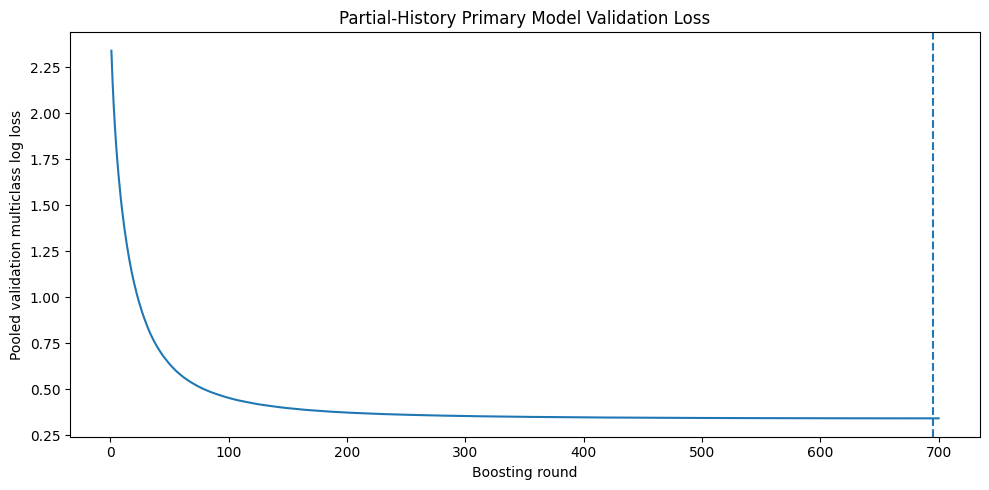

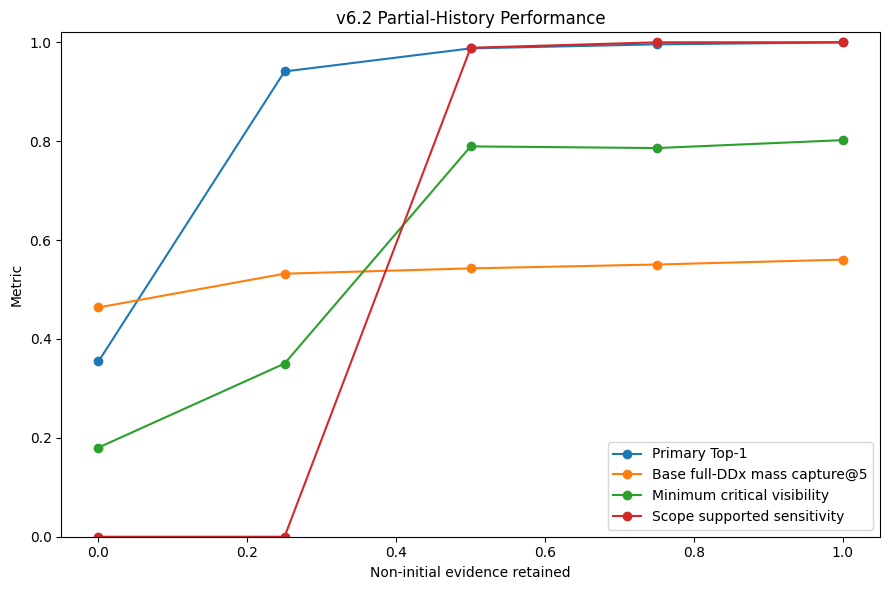

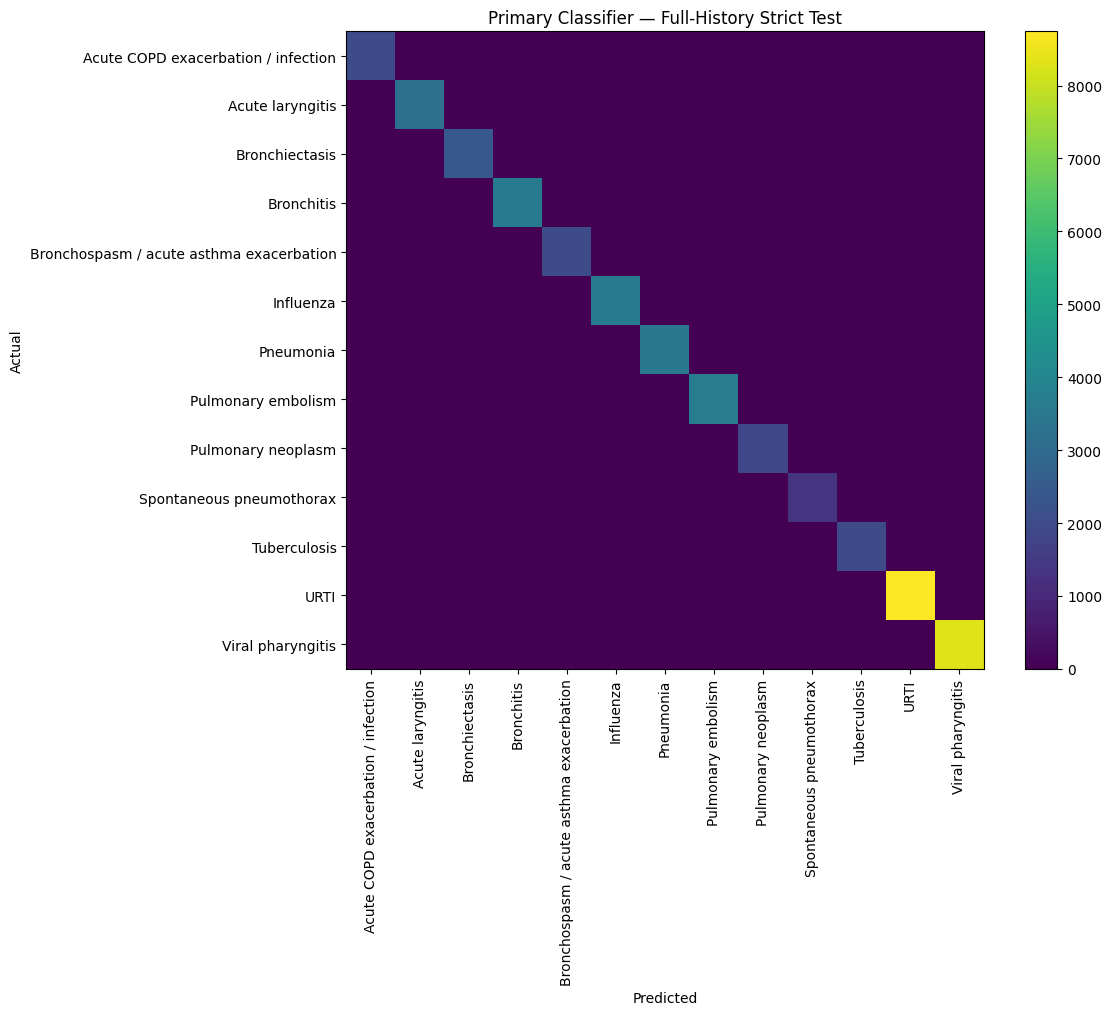

,feature,importance
0,EVIDENCE::E_151,0.127968
1,EVIDENCE::E_191,0.080764
2,EVIDENCE::E_131_@_V_12,0.062848
3,EVIDENCE::E_21,0.045813
4,EVIDENCE::E_131_@_V_10,0.044117
5,EVIDENCE::E_54_@_V_154,0.042027
6,EVIDENCE::E_54_@_V_71,0.037181
7,EVIDENCE::E_69,0.034702
8,EVIDENCE::E_212,0.033780
9,EVIDENCE::E_125,0.033168


In [24]:
# =========================================
# 24. Figures and model diagnostics
# =========================================
primary_history = primary_model.evals_result()["validation_0"]["mlogloss"]
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.plot(np.arange(1, len(primary_history) + 1), primary_history)
ax.axvline(primary_best_iteration + 1, linestyle="--")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Pooled validation multiclass log loss")
ax.set_title("Partial-History Primary Model Validation Loss")
plt.tight_layout()
primary_loss_figure = os.path.join(ARTIFACT_DIR, "primary_validation_loss.png")
fig.savefig(primary_loss_figure, dpi=200, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111)
ax.plot(
    primary_stage_metrics_df["retention_fraction"],
    primary_stage_metrics_df["top1_accuracy"],
    marker="o",
    label="Primary Top-1",
)
base_plot = DDX_STAGE_METRICS_DF.sort_values("retention_fraction")
ax.plot(
    base_plot["retention_fraction"],
    base_plot["full_official_ddx_probability_mass_capture_at_5"],
    marker="o",
    label="Base full-DDx mass capture@5",
)
critical_visibility_plot = (
    critical_visibility_stage_df
    .groupby("retention_fraction")[
        "combined_visibility_recall_at_5_plus_considerations"
    ]
    .min()
    .reset_index()
    .sort_values("retention_fraction")
)
ax.plot(
    critical_visibility_plot["retention_fraction"],
    critical_visibility_plot[
        "combined_visibility_recall_at_5_plus_considerations"
    ],
    marker="o",
    label="Minimum critical visibility",
)
ax.plot(
    scope_stage_metrics_df["retention_fraction"],
    scope_stage_metrics_df["supported_scope_sensitivity"],
    marker="o",
    label="Scope supported sensitivity",
)
ax.set_xlabel("Non-initial evidence retained")
ax.set_ylabel("Metric")
ax.set_ylim(0, 1.02)
ax.set_title("v6.2 Partial-History Performance")
ax.legend()
plt.tight_layout()
partial_history_figure = os.path.join(ARTIFACT_DIR, "partial_history_performance.png")
fig.savefig(partial_history_figure, dpi=200, bbox_inches="tight")
plt.show()

confusion = confusion_matrix(y_test, primary_full_pred)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111)
image = ax.imshow(confusion)
fig.colorbar(image, ax=ax)
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Primary Classifier — Full-History Strict Test")
plt.tight_layout()
confusion_figure = os.path.join(ARTIFACT_DIR, "primary_confusion_matrix.png")
fig.savefig(confusion_figure, dpi=200, bbox_inches="tight")
plt.show()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": primary_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
display(importance_df.head(30))

In [25]:
# =====================================================
# 25. Save models, metrics, predictions, and metadata
# =====================================================
def json_safe(value):
    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    return value


primary_model.save_model(
    Path(ARTIFACT_DIR) / "primary_pathology_xgboost.json"
)
scope_model.save_model(
    Path(ARTIFACT_DIR) / "supported_scope_xgboost.json"
)

DDX_MODEL_DIR = Path(ARTIFACT_DIR) / "ddx_probability_models"
INCLUSION_MODEL_DIR = Path(ARTIFACT_DIR) / "candidate_inclusion_models"
CRITICAL_HEAD_MODEL_DIR = Path(ARTIFACT_DIR) / "critical_pathology_heads"
for directory in (
    DDX_MODEL_DIR,
    INCLUSION_MODEL_DIR,
    CRITICAL_HEAD_MODEL_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)


def safe_filename(name):
    return re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        name,
    ).strip("_")


ddx_model_files = {}
for condition, model in zip(class_names, ddx_models):
    relative = (
        f"ddx_probability_models/"
        f"{safe_filename(condition)}.json"
    )
    model.save_model(Path(ARTIFACT_DIR) / relative)
    ddx_model_files[condition] = relative

inclusion_model_files = {}
for condition, model in inclusion_models.items():
    relative = (
        f"candidate_inclusion_models/"
        f"{safe_filename(condition)}.json"
    )
    model.save_model(Path(ARTIFACT_DIR) / relative)
    inclusion_model_files[condition] = relative

critical_head_model_files = {}
for condition, model in safety_models.items():
    relative = (
        f"critical_pathology_heads/"
        f"{safe_filename(condition)}.json"
    )
    model.save_model(Path(ARTIFACT_DIR) / relative)
    critical_head_model_files[condition] = relative

preprocessing_bundle = {
    "label_encoder": label_encoder,
    "evidence_encoder": evidence_encoder,
    "scope_vectorizer": scope_vectorizer,
    "feature_names": feature_names,
    "class_names": class_names,
    "active_pathologies": active_pathologies,
    "primary_temperatures": primary_temperatures,
    "primary_confidence_thresholds": primary_confidence_thresholds,
    "scope_thresholds_by_level": scope_thresholds_by_level,
    "scope_policy_config": scope_policy_config,
    "critical_consideration_target_conditions": (
        CRITICAL_CONSIDERATION_TARGET_CONDITIONS
    ),
    "critical_consideration_thresholds_by_level": (
        critical_consideration_thresholds_by_level
    ),
    "max_critical_considerations_per_case": (
        MAX_CRITICAL_CONSIDERATIONS_PER_CASE
    ),
    "inclusion_temperatures_by_level": (
        inclusion_temperatures_by_level
    ),
    "critical_head_thresholds_by_level": (
        safety_thresholds_by_level
    ),
    "evaluation_retention_levels": EVALUATION_RETENTION_LEVELS,
    "class_evidence_prevalence": class_evidence_prevalence,
    "question_groups": question_groups,
    "evidence_metadata": evidence_metadata_raw,
    "questionnaire_contract": {
        "positive_evidence_codes": (
            "Only positive/value evidence tokens sent to the models."
        ),
        "answered_question_codes": (
            "All answered non-initial question base codes, including negatives."
        ),
        "eligible_question_codes": (
            "All non-initial questions eligible in the active questionnaire."
        ),
    },
    "research_warning": (
        "Synthetic DDXPlus research models. Scores are not clinical probabilities."
    ),
}
preprocessing_path = Path(ARTIFACT_DIR) / "preprocessing_bundle.joblib"
joblib.dump(preprocessing_bundle, preprocessing_path)

portable_metadata = {
    "version": "v6.2",
    "primary_model_file": "primary_pathology_xgboost.json",
    "scope_model_file": "supported_scope_xgboost.json",
    "ddx_model_files": ddx_model_files,
    "inclusion_model_files": inclusion_model_files,
    "critical_head_model_files": critical_head_model_files,
    "class_names": class_names,
    "feature_names": feature_names,
    "scope_thresholds_by_level": scope_thresholds_by_level,
    "scope_policy_config": scope_policy_config,
    "critical_consideration_thresholds_by_level": (
        critical_consideration_thresholds_by_level
    ),
    "max_critical_considerations_per_case": (
        MAX_CRITICAL_CONSIDERATIONS_PER_CASE
    ),
    "inclusion_temperatures_by_level": (
        inclusion_temperatures_by_level
    ),
    "primary_temperatures": primary_temperatures,
    "primary_confidence_thresholds": primary_confidence_thresholds,
    "critical_head_thresholds_by_level": safety_thresholds_by_level,
    "research_warning": (
        "Synthetic DDXPlus research package. Not clinically validated."
    ),
}
with open(
    Path(ARTIFACT_DIR) / "portable_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(json_safe(portable_metadata), file, indent=2)

# Tables and reports.
exports = [
    (raw_split_summary, "raw_split_summary.csv", False),
    (full_class_counts, "all_pathology_counts.csv", True),
    (respiratory_full_counts, "respiratory_counts_available.csv", True),
    (respiratory_counts_used, "respiratory_counts_used.csv", True),
    (age_audit, "age_audit.csv", False),
    (sex_counts, "sex_counts.csv", True),
    (training_view_summary, "respiratory_training_views.csv", False),
    (primary_stage_metrics_df, "primary_stage_metrics.csv", False),
    (primary_classification_report_df, "primary_full_history_classification_report.csv", True),
    (ddx_training_summary_df, "ddx_training_summary.csv", False),
    (inclusion_training_summary_df, "inclusion_training_summary.csv", False),
    (critical_consideration_threshold_tuning_df, "critical_consideration_threshold_tuning.csv", False),
    (critical_consideration_selected_policy_df, "critical_consideration_selected_policy.csv", False),
    (critical_consideration_stage_audit_df, "critical_consideration_stage_audit.csv", False),
    (critical_consideration_condition_audit_df, "critical_consideration_condition_audit.csv", False),
    (critical_visibility_stage_df, "critical_visibility_stage_metrics.csv", False),
    (DDX_STAGE_METRICS_DF, "ddx_stage_metrics.csv", False),
    (DDX_PER_CONDITION_STAGE_DF, "ddx_per_condition_stage_metrics.csv", False),
    (safety_training_summary_df, "critical_pathology_head_training_summary.csv", False),
    (safety_stage_metrics_df, "critical_pathology_head_stage_metrics.csv", False),
    (scope_threshold_validation_df, "scope_threshold_validation.csv", False),
    (scope_stage_metrics_df, "scope_stage_metrics.csv", False),
    (scope_per_condition_df, "scope_per_condition_stage_metrics.csv", False),
    (release_gates_df, "synthetic_release_gates.csv", False),
    (end_to_end_stage_metrics_df, "end_to_end_stage_metrics.csv", False),
    (robustness_runs_df, "partial_history_robustness_all_runs.csv", False),
    (robustness_summary_df, "partial_history_robustness_summary.csv", False),
    (importance_df, "primary_feature_importance.csv", False),
]
for frame, filename, include_index in exports:
    frame.to_csv(
        Path(ARTIFACT_DIR) / filename,
        index=include_index,
    )

with open(
    Path(ARTIFACT_DIR) / "duplicate_audit.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(json_safe(duplicate_audit), file, indent=2)
with open(
    Path(ARTIFACT_DIR) / "strict_overlap_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(json_safe(strict_overlap_summary), file, indent=2)
with open(
    Path(ARTIFACT_DIR) / "synthetic_readiness_status.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(json_safe(synthetic_readiness_status), file, indent=2)

# Strict full-history predictions. The base Top-5 is the only ranked list.
full_base = base_normalized_by_level[1.0]
full_top5 = base_topk_by_level[1.0]
full_consideration_audit = critical_consideration_audit_by_level[1.0]
primary_order = np.argsort(
    primary_full_prob,
    axis=1,
)[:, -k5:][:, ::-1]

prediction_export = pd.DataFrame({
    "test_row": np.arange(len(test_df)),
    "age": test_df["AGE"].to_numpy(),
    "sex": test_df["SEX"].to_numpy(),
    "ground_truth_pathology": test_df["PATHOLOGY"].to_numpy(),
    "primary_top1": [
        class_names[index]
        for index in primary_order[:, 0]
    ],
    "primary_top1_confidence": primary_full_prob.max(axis=1),
    "base_ddx_top1": [
        class_names[index]
        for index in full_top5[:, 0]
    ],
    "critical_consideration_count": full_consideration_audit[
        "consideration_count"
    ],
})

for rank_index in range(k5):
    prediction_export[f"primary_rank_{rank_index + 1}"] = [
        class_names[index]
        for index in primary_order[:, rank_index]
    ]
    prediction_export[
        f"primary_rank_{rank_index + 1}_confidence"
    ] = primary_full_prob[
        np.arange(len(test_df)),
        primary_order[:, rank_index],
    ]
    prediction_export[f"base_ddx_rank_{rank_index + 1}"] = [
        class_names[index]
        for index in full_top5[:, rank_index]
    ]
    prediction_export[
        f"base_ddx_rank_{rank_index + 1}_relevance"
    ] = full_base[
        np.arange(len(test_df)),
        full_top5[:, rank_index],
    ]

for slot in range(MAX_CRITICAL_CONSIDERATIONS_PER_CASE):
    indices = full_consideration_audit[
        "consideration_indices"
    ][:, slot]
    prediction_export[
        f"critical_consideration_{slot + 1}"
    ] = [
        class_names[int(index)] if index >= 0 else None
        for index in indices
    ]
    prediction_export[
        f"critical_consideration_{slot + 1}_score"
    ] = full_consideration_audit[
        "consideration_probabilities"
    ][:, slot]
    prediction_export[
        f"critical_consideration_{slot + 1}_margin"
    ] = full_consideration_audit[
        "consideration_margins"
    ][:, slot]

prediction_export.to_csv(
    Path(ARTIFACT_DIR) / "strict_full_history_top5_predictions.csv",
    index=False,
)

run_summary = {
    "version": "v6.2",
    "research_warning": (
        "Synthetic DDXPlus results are not clinical evidence."
    ),
    "environment": {
        "python": platform.python_version(),
        "gpu": GPU_NAME,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgb.__version__,
    },
    "run_mode": RUN_MODE,
    "dataset": {
        "raw_split_summary": raw_split_summary.to_dict(orient="records"),
        "training_records": int(len(train_df)),
        "strict_validation_records": int(len(val_df)),
        "strict_test_records": int(len(test_df)),
        "strict_scope_validation_records": int(len(scope_val_df)),
        "strict_scope_test_records": int(len(scope_test_df)),
        "duplicate_audit": duplicate_audit,
        "strict_overlap_summary": strict_overlap_summary,
    },
    "scope": {
        "training_minutes": scope_training_seconds / 60,
        "best_iteration": scope_best_iteration,
        "best_validation_logloss": scope_best_score,
        "thresholds_by_level": scope_thresholds_by_level,
        "threshold_validation": scope_threshold_validation_df.to_dict(orient="records"),
        "stage_metrics": scope_stage_metrics_df.to_dict(orient="records"),
    },
    "primary": {
        "training_minutes": primary_training_seconds / 60,
        "best_iteration": primary_best_iteration,
        "best_validation_logloss": primary_best_score,
        "stage_metrics": primary_stage_metrics_df.to_dict(orient="records"),
    },
    "differential": {
        "training_minutes": ddx_training_seconds / 60,
        "base_stage_metrics": DDX_STAGE_METRICS_DF.to_dict(orient="records"),
        "critical_consideration_thresholds_by_level": (
            critical_consideration_thresholds_by_level
        ),
        "critical_consideration_stage_audit": (
            critical_consideration_stage_audit_df.to_dict(orient="records")
        ),
        "critical_visibility": critical_visibility_stage_df.to_dict(orient="records"),
    },
    "release_gates": release_gates_df.to_dict(orient="records"),
    "end_to_end": end_to_end_stage_metrics_df.to_dict(orient="records"),
    "partial_history_robustness": robustness_summary_df.to_dict(orient="records"),
    "readiness": synthetic_readiness_status,
}
with open(
    Path(ARTIFACT_DIR) / "run_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(json_safe(run_summary), file, indent=2)

readme = f"""RESPIRATORY DDX XGBOOST V6.2 SYNTHETIC RESEARCH RESULTS
=========================================================

WARNING: DDXPlus is synthetic. This package is not clinically validated.

Run mode: {RUN_MODE}
Respiratory train: {len(train_df)}
Strict respiratory validation: {len(val_df)}
Strict respiratory test: {len(test_df)}
Strict full-scope test: {len(scope_test_df)}

Three-state policy:
  SUPPORTED_SCOPE
  UNSUPPORTED_SCOPE
  INSUFFICIENT_INFORMATION

Critical DDx presentation:
  Original probability-ranked Top-5 remains unchanged
  + up to {MAX_CRITICAL_CONSIDERATIONS_PER_CASE} separate critical considerations
  + condition-specific validation thresholds
  + consideration precision and false-addition auditing

All numeric synthetic gates passed: {synthetic_readiness_status['all_numeric_research_gates_passed']}
Evidence metadata available: {synthetic_readiness_status['doctor_readable_evidence_metadata_available']}
Clinical readiness: False

Critical-pathology heads predict synthetic pathology labels. They are not emergency or severity detectors.
Use portable_scope_gated_inference.py only.
"""
with open(
    Path(ARTIFACT_DIR) / "README_RESULTS.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(readme)

print("Core artifacts saved to:", ARTIFACT_DIR)

Core artifacts saved to: /kaggle/working/respiratory_ddx_artifacts_v6_2_1


In [26]:
# ==================================================
# 26. Real respiratory encounter collection schema
# ==================================================
real_encounter_schema = pd.DataFrame([
    ("encounter_id", "string", "De-identified encounter key"),
    ("patient_id_hash", "string", "De-identified longitudinal patient key"),
    ("site_id", "string", "Hospital/clinic identifier"),
    ("encounter_timestamp", "datetime", "Needed for temporal validation"),
    ("age", "number", "Age at encounter"),
    ("sex_at_birth", "category", "Recorded sex"),
    ("chief_complaint", "text/category", "Initial complaint"),
    ("symptoms_and_duration", "structured", "Symptoms, duration, severity"),
    ("spo2", "number", "Measured oxygen saturation"),
    ("respiratory_rate", "number", "Measured respiratory rate"),
    ("temperature", "number", "Measured temperature"),
    ("heart_rate", "number", "Measured pulse"),
    ("blood_pressure", "number", "Measured blood pressure"),
    ("auscultation", "structured", "Wheeze/crackles/air entry"),
    ("laboratory_results", "structured", "Relevant laboratory values"),
    ("spirometry", "structured", "FEV1/FVC and related measurements"),
    ("imaging_findings", "structured", "X-ray/CT findings"),
    ("medications", "structured", "Current medications"),
    ("allergies", "structured", "Drug and other allergies"),
    ("clinician_differential", "multilabel_ranked", "Ranked clinician DDx"),
    ("final_diagnosis", "category", "Clinician-confirmed final diagnosis"),
    ("treatment", "structured", "Treatment provided"),
    ("outcome", "structured", "Follow-up/outcome"),
], columns=["field", "type", "description"])
real_encounter_schema.to_csv(
    Path(ARTIFACT_DIR) / "real_respiratory_encounter_schema.csv",
    index=False,
)
display(real_encounter_schema)

,field,type,description
0,encounter_id,string,De-identified encounter key
1,patient_id_hash,string,De-identified longitudinal patient key
2,site_id,string,Hospital/clinic identifier
3,encounter_timestamp,datetime,Needed for temporal validation
4,age,number,Age at encounter
5,sex_at_birth,category,Recorded sex
6,chief_complaint,text/category,Initial complaint
7,symptoms_and_duration,structured,"Symptoms, duration, severity"
8,spo2,number,Measured oxygen saturation
9,respiratory_rate,number,Measured respiratory rate


In [27]:
# ===========================================================
# 27. Portable scope-gated v6.2 inference script
# ===========================================================
portable_script = r'''# Portable inference for the synthetic DDXPlus XGBoost v6.2 package.
# This program is not clinically validated. It does not diagnose emergencies,
# recommend treatment, or generate prescriptions.
from pathlib import Path
import json
import joblib
import numpy as np
from scipy import sparse
import xgboost as xgb

ARTIFACT_DIR = Path(__file__).resolve().parent
bundle = joblib.load(
    ARTIFACT_DIR / "preprocessing_bundle.joblib"
)
with open(
    ARTIFACT_DIR / "portable_metadata.json",
    "r",
    encoding="utf-8",
) as file:
    metadata = json.load(file)

primary_model = xgb.XGBClassifier()
primary_model.load_model(
    ARTIFACT_DIR / metadata["primary_model_file"]
)
scope_model = xgb.XGBClassifier()
scope_model.load_model(
    ARTIFACT_DIR / metadata["scope_model_file"]
)

ddx_models = {}
for condition, relative_path in metadata[
    "ddx_model_files"
].items():
    model = xgb.XGBRegressor()
    model.load_model(ARTIFACT_DIR / relative_path)
    ddx_models[condition] = model

inclusion_models = {}
for condition, relative_path in metadata[
    "inclusion_model_files"
].items():
    model = xgb.XGBClassifier()
    model.load_model(ARTIFACT_DIR / relative_path)
    inclusion_models[condition] = model

critical_head_models = {}
for condition, relative_path in metadata[
    "critical_head_model_files"
].items():
    model = xgb.XGBClassifier()
    model.load_model(ARTIFACT_DIR / relative_path)
    critical_head_models[condition] = model

CLASS_NAMES = bundle["class_names"]
CLASS_TO_INDEX = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}
EPS = 1e-12


def evidence_base_code(code):
    return str(code).split("_@_", 1)[0]


def questionnaire_completion_fraction(
    answered_question_codes,
    eligible_question_codes,
):
    answered = {
        evidence_base_code(code)
        for code in answered_question_codes
    }
    eligible = {
        evidence_base_code(code)
        for code in eligible_question_codes
    }
    if not eligible:
        raise ValueError(
            "eligible_question_codes must contain at least one item."
        )
    answered_count = len(answered & eligible)
    return float(answered_count / len(eligible)), int(answered_count)


def stage_code(completion_fraction):
    if completion_fraction <= 0:
        return 0.0
    if completion_fraction < 0.5:
        return 1.0
    if completion_fraction < 1.0:
        return 2.0
    return 3.0


def dense_matrix(
    age,
    sex,
    positive_evidence_count,
    completion_fraction,
):
    sex_value = {
        "F": 0.0,
        "M": 1.0,
    }.get(str(sex).upper(), -1.0)
    values = np.array([[
        float(age),
        sex_value,
        float(positive_evidence_count),
        float(completion_fraction),
        float(positive_evidence_count <= 0),
        stage_code(float(completion_fraction)),
    ]], dtype=np.float32)
    return sparse.csr_matrix(values)


def respiratory_matrix(
    age,
    sex,
    evidence_codes,
    initial_evidence,
    completion_fraction,
):
    tokens = sorted(set(
        [str(code) for code in evidence_codes]
        + [f"INITIAL::{initial_evidence}"]
    ))
    encoded = bundle["evidence_encoder"].transform([tokens])
    return sparse.hstack([
        dense_matrix(
            age,
            sex,
            len(set(evidence_codes)),
            completion_fraction,
        ),
        encoded,
    ], format="csr", dtype=np.float32)


def scope_matrix(
    age,
    sex,
    evidence_codes,
    initial_evidence,
    completion_fraction,
):
    text = (
        " ".join(str(code) for code in evidence_codes)
        + " INITIAL__"
        + str(initial_evidence)
    )
    encoded = bundle["scope_vectorizer"].transform(
        [text]
    ).astype(np.float32)
    return sparse.hstack([
        dense_matrix(
            age,
            sex,
            len(set(evidence_codes)),
            completion_fraction,
        ),
        encoded,
    ], format="csr", dtype=np.float32)


def temperature_scale(probabilities, temperature):
    probabilities = np.clip(probabilities, EPS, 1.0)
    logits = np.log(probabilities) / float(temperature)
    logits -= logits.max(axis=1, keepdims=True)
    exp_values = np.exp(logits)
    return exp_values / exp_values.sum(
        axis=1,
        keepdims=True,
    )


def binary_temperature_scale(probability, temperature):
    probability = np.clip(
        probability,
        EPS,
        1.0 - EPS,
    )
    logit = np.log(
        probability / (1.0 - probability)
    ) / float(temperature)
    return float(1.0 / (1.0 + np.exp(-logit)))


def nearest_bucket(completion_fraction):
    return min(
        bundle["evaluation_retention_levels"],
        key=lambda value: abs(
            float(value) - float(completion_fraction)
        ),
    )


def nearest_scope_bucket(completion_fraction):
    return min(
        bundle["scope_thresholds_by_level"],
        key=lambda value: abs(
            float(value) - float(completion_fraction)
        ),
    )


def metadata_question(base_code):
    details = bundle.get(
        "evidence_metadata",
        {},
    ).get(base_code, {})
    if not isinstance(details, dict):
        return None
    for key in (
        "question_en",
        "question",
        "name_en",
        "name",
        "description_en",
        "description",
    ):
        value = details.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()
    return None


def suggest_next_questions(
    observed_evidence_codes,
    ddx_scores,
    question_count=5,
    top_candidate_count=5,
):
    prevalence = np.asarray(
        bundle["class_evidence_prevalence"],
        dtype=np.float32,
    )
    question_groups = bundle["question_groups"]
    observed_bases = {
        evidence_base_code(code)
        for code in observed_evidence_codes
    }
    scores = np.asarray(ddx_scores, dtype=np.float64)
    top_indices = np.argsort(scores)[::-1][
        :min(top_candidate_count, len(CLASS_NAMES))
    ]
    weights = scores[top_indices]
    if weights.sum() <= 0:
        weights = np.ones(
            len(top_indices),
            dtype=np.float64,
        )
    weights = weights / weights.sum()

    rows = []
    for base_code, column_indices in question_groups.items():
        if base_code in observed_bases:
            continue
        candidate_prevalence = prevalence[
            np.ix_(top_indices, column_indices)
        ]
        weighted_mean = np.sum(
            weights[:, None] * candidate_prevalence,
            axis=0,
        )
        weighted_variance = np.sum(
            weights[:, None]
            * (
                candidate_prevalence
                - weighted_mean[None, :]
            ) ** 2,
            axis=0,
        )
        disagreement = float(
            weighted_variance.max(initial=0.0)
        )
        if disagreement <= 0:
            continue
        rows.append({
            "evidence_code": base_code,
            "candidate_disagreement_score": disagreement,
            "question": metadata_question(base_code),
        })
    rows.sort(
        key=lambda item: item[
            "candidate_disagreement_score"
        ],
        reverse=True,
    )
    return rows[:int(question_count)]


def base_ddx_scores(matrix, primary):
    scores = np.array([
        max(
            0.0,
            float(ddx_models[condition].predict(matrix)[0]),
        )
        for condition in CLASS_NAMES
    ], dtype=np.float32)
    if scores.sum() > 0:
        return scores / scores.sum()
    return primary.copy()


def inclusion_scores(matrix, bucket):
    output = {}
    for condition, model in inclusion_models.items():
        raw = float(model.predict_proba(matrix)[0, 1])
        temperature = bundle[
            "inclusion_temperatures_by_level"
        ][condition][bucket]
        output[condition] = binary_temperature_scale(
            raw,
            temperature,
        )
    return output


def critical_considerations(
    base_scores,
    inclusion,
    bucket,
    top_k,
):
    base_order = np.argsort(base_scores)[::-1]
    base_topk = base_order[:top_k]
    thresholds = bundle[
        "critical_consideration_thresholds_by_level"
    ][bucket]
    eligible = []
    for condition in bundle[
        "critical_consideration_target_conditions"
    ]:
        class_index = CLASS_TO_INDEX[condition]
        if class_index in base_topk:
            continue
        threshold = float(thresholds[condition])
        probability = float(inclusion[condition])
        if probability < threshold:
            continue
        margin = (
            probability - threshold
        ) / max(1.0 - threshold, 1e-6)
        eligible.append((margin, probability, condition))

    eligible.sort(reverse=True)
    maximum = int(
        bundle["max_critical_considerations_per_case"]
    )
    return [
        {
            "condition": condition,
            "candidate_inclusion_score": float(probability),
            "validation_threshold": float(thresholds[condition]),
            "normalized_margin": float(margin),
            "separate_from_ranked_top5": True,
        }
        for margin, probability, condition
        in eligible[:maximum]
    ]

def critical_pathology_signals(matrix, bucket):
    rows = []
    thresholds = bundle[
        "critical_head_thresholds_by_level"
    ]
    for condition, model in critical_head_models.items():
        score = float(model.predict_proba(matrix)[0, 1])
        threshold = float(thresholds[condition][bucket])
        rows.append({
            "condition": condition,
            "critical_pathology_score": score,
            "signal_threshold": threshold,
            "signal": bool(score >= threshold),
            "research_only": True,
        })
    rows.sort(
        key=lambda item: item["critical_pathology_score"],
        reverse=True,
    )
    return rows


def predict(
    age,
    sex,
    evidence_codes,
    initial_evidence,
    answered_question_codes,
    eligible_question_codes,
    top_k=5,
):
    evidence_codes = [str(code) for code in evidence_codes]
    initial_evidence = str(initial_evidence)
    completion_fraction, answered_count = (
        questionnaire_completion_fraction(
            answered_question_codes,
            eligible_question_codes,
        )
    )
    bucket = nearest_bucket(completion_fraction)

    s_matrix = scope_matrix(
        age,
        sex,
        evidence_codes,
        initial_evidence,
        completion_fraction,
    )
    scope_score = float(
        scope_model.predict_proba(s_matrix)[0, 1]
    )
    scope_bucket = nearest_scope_bucket(completion_fraction)
    thresholds = bundle[
        "scope_thresholds_by_level"
    ][scope_bucket]
    policy = bundle["scope_policy_config"]
    direct_allowed = (
        completion_fraction
        >= policy["minimum_completion_for_direct_decision"]
        and answered_count
        >= policy["minimum_information_items_for_direct_decision"]
    )
    if not direct_allowed:
        state = "INSUFFICIENT_INFORMATION"
    elif scope_score >= thresholds["supported_threshold"]:
        state = "SUPPORTED_SCOPE"
    elif scope_score <= thresholds["unsupported_threshold"]:
        state = "UNSUPPORTED_SCOPE"
    else:
        state = "INSUFFICIENT_INFORMATION"

    r_matrix = respiratory_matrix(
        age,
        sex,
        evidence_codes,
        initial_evidence,
        completion_fraction,
    )
    primary_raw = primary_model.predict_proba(r_matrix)
    primary = temperature_scale(
        primary_raw,
        bundle["primary_temperatures"][bucket],
    )[0]
    primary_confidence_accepted = bool(
        primary.max()
        >= bundle["primary_confidence_thresholds"][bucket]
    )
    base = base_ddx_scores(r_matrix, primary)
    inclusion = inclusion_scores(r_matrix, bucket)
    signals = critical_pathology_signals(r_matrix, bucket)
    positive_signals = [row for row in signals if row["signal"]]

    if state == "INSUFFICIENT_INFORMATION":
        return {
            "status": state,
            "completion_fraction": completion_fraction,
            "scope_supported_score": scope_score,
            "primary_confidence_accepted": primary_confidence_accepted,
            "next_questions": suggest_next_questions(
                list(answered_question_codes) + [initial_evidence],
                base,
                question_count=5,
            ),
            "candidates": [],
            "possible_critical_pathology_signals": positive_signals,
            "research_warning": (
                "Critical-pathology signals are synthetic label "
                "predictions, not emergency or severity decisions."
            ),
        }

    if state == "UNSUPPORTED_SCOPE":
        return {
            "status": state,
            "completion_fraction": completion_fraction,
            "scope_supported_score": scope_score,
            "primary_confidence_accepted": primary_confidence_accepted,
            "next_questions": [],
            "candidates": [],
            "possible_critical_pathology_signals": [],
        }

    order = np.argsort(base)[::-1][
        :min(int(top_k), len(CLASS_NAMES))
    ]
    candidates = [
        {
            "rank": rank,
            "condition": CLASS_NAMES[int(index)],
            "base_ddx_relevance_score": float(base[index]),
            "primary_model_confidence": float(primary[index]),
        }
        for rank, index in enumerate(order, start=1)
    ]
    considerations = critical_considerations(
        base,
        inclusion,
        bucket,
        min(int(top_k), len(CLASS_NAMES)),
    )
    return {
        "status": state,
        "completion_fraction": completion_fraction,
        "scope_supported_score": scope_score,
        "primary_confidence_accepted": primary_confidence_accepted,
        "next_questions": [],
        "candidates": candidates,
        "additional_critical_considerations": considerations,
        "possible_critical_pathology_signals": positive_signals,
    }

'''

portable_script_path = (
    Path(ARTIFACT_DIR)
    / "portable_scope_gated_inference.py"
)
portable_script_path.write_text(
    portable_script.strip() + "\n",
    encoding="utf-8",
)
compile(
    portable_script_path.read_text(encoding="utf-8"),
    str(portable_script_path),
    "exec",
)
print(
    "Portable inference script saved and syntax-validated:",
    portable_script_path,
)

Portable inference script saved and syntax-validated: /kaggle/working/respiratory_ddx_artifacts_v6_2_1/portable_scope_gated_inference.py


In [28]:
# ========================================================
# 28. Artifact validation, SHA-256 manifest, and direct ZIP
# ========================================================
required_artifacts = [
    "primary_pathology_xgboost.json",
    "supported_scope_xgboost.json",
    "preprocessing_bundle.joblib",
    "portable_metadata.json",
    "portable_scope_gated_inference.py",
    "run_summary.json",
    "synthetic_release_gates.csv",
    "scope_threshold_validation.csv",
    "scope_stage_metrics.csv",
    "scope_per_condition_stage_metrics.csv",
    "primary_stage_metrics.csv",
    "ddx_stage_metrics.csv",
    "ddx_per_condition_stage_metrics.csv",
    "critical_consideration_threshold_tuning.csv",
    "critical_consideration_selected_policy.csv",
    "critical_consideration_stage_audit.csv",
    "critical_consideration_condition_audit.csv",
    "critical_visibility_stage_metrics.csv",
    "critical_pathology_head_stage_metrics.csv",
    "critical_pathology_head_training_summary.csv",
    "end_to_end_stage_metrics.csv",
    "partial_history_robustness_summary.csv",
    "strict_full_history_top5_predictions.csv",
    "real_respiratory_encounter_schema.csv",
    "README_RESULTS.txt",
]
missing_artifacts = [
    name
    for name in required_artifacts
    if not (Path(ARTIFACT_DIR) / name).exists()
]
if missing_artifacts:
    raise RuntimeError(
        "ZIP creation stopped; missing artifacts: "
        + ", ".join(missing_artifacts)
    )

if len(list(
    (Path(ARTIFACT_DIR) / "ddx_probability_models").glob("*.json")
)) != n_classes:
    raise RuntimeError(
        "Expected one DDx probability model per supported class."
    )
if len(list(
    (Path(ARTIFACT_DIR) / "candidate_inclusion_models").glob("*.json")
)) != len(CRITICAL_CONSIDERATION_TARGET_CONDITIONS):
    raise RuntimeError(
        "Candidate-inclusion model count mismatch."
    )
if len(list(
    (Path(ARTIFACT_DIR) / "critical_pathology_heads").glob("*.json")
)) != len(CRITICAL_RESPIRATORY_CONDITIONS):
    raise RuntimeError(
        "Critical-pathology head model count mismatch."
    )

for unsafe_name in (
    "portable_inference_template.py",
    "portable_primary_only_inference.py",
):
    if (Path(ARTIFACT_DIR) / unsafe_name).exists():
        raise RuntimeError(
            f"Unsafe legacy inference script found: {unsafe_name}"
        )

portable_path = Path(ARTIFACT_DIR) / "portable_scope_gated_inference.py"
portable_text = portable_path.read_text(encoding="utf-8")
compile(portable_text, str(portable_path), "exec")
if "displaced_rank5" in portable_text or "apply_single_patient_rescue" in portable_text:
    raise RuntimeError(
        "Legacy rank-replacement logic remains in portable inference."
    )

manifest_rows = []
for artifact_path in sorted(Path(ARTIFACT_DIR).rglob("*")):
    if (
        not artifact_path.is_file()
        or artifact_path.name == "artifact_manifest_sha256.csv"
    ):
        continue
    digest = hashlib.sha256()
    with open(artifact_path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)
    manifest_rows.append({
        "relative_path": str(
            artifact_path.relative_to(ARTIFACT_DIR)
        ),
        "size_bytes": artifact_path.stat().st_size,
        "sha256": digest.hexdigest(),
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = Path(ARTIFACT_DIR) / "artifact_manifest_sha256.csv"
manifest_df.to_csv(manifest_path, index=False)

zip_path = shutil.make_archive(
    ZIP_BASENAME,
    "zip",
    ARTIFACT_DIR,
)
zip_size_mb = os.path.getsize(zip_path) / (1024 ** 2)
if zip_size_mb < 1.0:
    raise RuntimeError(
        f"ZIP is unexpectedly small ({zip_size_mb:.3f} MB). "
        "An earlier cell may have failed."
    )

print("Artifact validation passed.")
print("Manifest entries:", len(manifest_df))
print("ZIP created:", zip_path)
print(f"ZIP size: {zip_size_mb:.2f} MB")
display(FileLink(zip_path))

Artifact validation passed.
Manifest entries: 65
ZIP created: /kaggle/working/respiratory_ddx_results_v6_2_1.zip
ZIP size: 35.91 MB


/kaggle/working/respiratory_ddx_results_v6_2_1.zip

# Interpretation rules

1. v6.2 preserves the validated partial-history and three-state scope foundation.
2. The official ranked differential is always the original probability-regressor Top-5.
3. Critical candidate-inclusion models produce a separate list of at most two additional considerations; they never replace a ranked diagnosis.
4. Consideration thresholds are selected on validation data only; the strict test split is used once for final evaluation.
5. Report combined critical visibility, consideration precision, false-addition rate, and average list size.
6. At half history, routing a supported patient to `INSUFFICIENT_INFORMATION` is safe abstention. The blocking error is incorrectly routing that patient to `UNSUPPORTED_SCOPE`.
7. A low-information case must normally become `INSUFFICIENT_INFORMATION`, not `UNSUPPORTED_SCOPE`.
8. Critical-pathology heads predict synthetic final pathology labels. They are not emergency, severity, instability, or referral models.
9. During insufficient-information states, critical-pathology outputs are only research signals and must be accompanied by follow-up questions.
10. The backend must calculate the completion proxy from answered and eligible questionnaire items. A frontend must not submit an arbitrary completion fraction.
11. Human-readable questions require official evidence metadata. Without it, the question module is code-level only.
12. Report both closed-world 13-condition ranking and complete official-DDx coverage.
13. Passing every synthetic gate does not establish clinical readiness.
14. Do not add MedGemma, RAG, treatment generation, or prescription generation until real clinician-labelled data and independent validation exist.